# Utah Jazz 2024-25 — Analisi esplorativa del roster

Questo notebook raccoglie l'analisi esplorativa (EDA) del roster degli Utah Jazz nella stagione 2024-25: minutaggio, produzione offensiva e difensiva, efficienza al tiro, shot chart, stipendi e un primo tentativo di classificazione dei giocatori per ruolo tattico. È il lavoro propedeutico al modello decisionale di ricostruzione della franchigia sviluppato nei Capitoli 3 e 4 della tesi *"Data Science per la Ricostruzione di una Franchigia NBA: il Caso Utah Jazz"*, entrambi richiamati nelle ultime due sezioni di questo notebook.

**Indice**
1. [Setup e caricamento dati](#Setup-e-caricamento-dati)
2. [Analisi del roster](#Roster-Analysis)
3. [Contributo offensivo e difensivo per ruolo](#Contributo-offensivo-e-difensivo-per-ruolo)
4. [Confronto con le squadre ai playoff](#Confronto-con-le-squadre-ai-playoff)
5. [Diagnosi dell'efficienza offensiva](#Diagnosi-dell'efficienza-offensiva)
6. [Punti per ruolo: Jazz vs playoff, e shot chart](#Punti-per-ruolo-Jazz-vs-playoff)
7. [Stipendi](#Stipendi)
8. [Peso offensivo/difensivo e clustering](#Peso-offensivo-difensivo-e-clustering)
9. [Player Analysis: report automatici per giocatore](#Player-Analysis)
10. [Decision-support model v4 (Capitolo 3)](#Decision-support-model-v4)
11. [NBA Draft 2025 (Capitolo 4)](#NBA-Draft-2025)

**Dati**: statistiche box-score 2024-25, tabelle salariali e shot location dei giocatori Jazz, più i dataset delle squadre ai playoff, dei free agent e dei prospect del draft, tutti in formato CSV nella cartella `data/` del progetto.


## Setup e caricamento dati

Librerie e dataset di base per l'analisi del roster: statistiche box-score Jazz, free agent, giocatori di lega, prospect draft e shot chart.

In [208]:
import pandas as pd
import numpy as np
import plotly.express as px

In [209]:
df = pd.read_csv("UtahJazz24-25clean.csv")
freeagents = pd.read_csv("freeagents.csv")
players = pd.read_csv("data/allleagueplayersandsalary.csv")
draft = pd.read_csv("draft/nbadraftplayers.csv")
utahshot = pd.read_csv("utahjazzshot.csv")

## Roster Analysis

Prima passata sui dati grezzi del roster: minuti, titolarità, produzione offensiva e difensiva per giocatore e per ruolo, sulla base del file `UtahJazz24-25clean.csv`.

**Minuti medi a partita per giocatore**, ordinati dal più al meno impiegato: è il primo indicatore di quanto ogni giocatore pesi nelle rotazioni di coach Hardy.

In [210]:
mp = df.groupby("Player")["MP"].mean().reset_index().sort_values("MP", ascending=False)
mp

,Player,MP
11,Keyonte George,31.5
13,Lauri Markkanen,31.4
7,John Collins,30.5
19,Walker Kessler,30.0
2,Collin Sexton,27.9
9,Jordan Clarkson,26.0
5,Isaiah Collier,25.9
18,Taylor Hendricks,25.0
10,KJ Martin,22.7
1,Cody Williams,21.2


In [211]:
fig = px.bar(
    mp,
    x="Player",
    y="MP",
    width = 800,
    height = 500,
    orientation="v",
    title = "Media minuti giocati per partita"
    )

fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)

fig.show()

In [212]:
df[["Player", "MP", "Pos"]].sort_values("MP", ascending=False)

,Player,MP,Pos
5,Keyonte George,31.5,PG
10,Lauri Markkanen,31.4,PF
2,John Collins,30.5,PF
9,Walker Kessler,30.0,C
16,Collin Sexton,27.9,SG
0,Jordan Clarkson,26.0,SG
1,Isaiah Collier,25.9,PG
7,Taylor Hendricks,25.0,PF
11,KJ Martin,22.7,SF
19,Cody Williams,21.2,SG


**Partite iniziate da titolare (Games Started)** per giocatore: a differenza dei minuti, misura il ruolo formale nello starting five nel corso della stagione.

In [213]:
gs = df.groupby("Player")["GS"].sum().reset_index().sort_values("GS", ascending=False)
gs

,Player,GS
2,Collin Sexton,61
19,Walker Kessler,58
13,Lauri Markkanen,47
5,Isaiah Collier,46
11,Keyonte George,35
7,John Collins,31
12,Kyle Filipowski,27
1,Cody Williams,21
8,Johnny Juzang,18
0,Brice Sensabaugh,15


In [214]:
fig = px.bar(
    gs,
    x="Player",
    y="GS",
    width = 800,
    height = 500,
    title = "Partite iniziate da titolare per giocatore"
)

fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)

fig.show()

**Starting five più utilizzato**: i 5 giocatori con più partite da titolare, con i rispettivi punti a partita.

In [215]:
starters = df.sort_values("GS", ascending=False).head(5)
starters[["Player", "Pos", "GS", "PTS"]]

,Player,Pos,GS,PTS
16,Collin Sexton,SG,61,18.4
9,Walker Kessler,C,58,11.1
10,Lauri Markkanen,PF,47,19.0
1,Isaiah Collier,PG,46,8.7
5,Keyonte George,PG,35,16.8


**Punti medi per ruolo (Pos)**: prima verifica di dove si concentra la produzione offensiva della squadra sulle cinque posizioni.

In [216]:
pts = df.groupby("Pos")["PTS"].mean().reset_index(name = "PTS per role").sort_values("PTS per role", ascending=False)
pts

,Pos,PTS per role
1,PF,14.233333
4,SG,10.260000
3,SF,8.666667
2,PG,8.425000
0,C,7.680000


In [217]:
fig = px.bar(
    pts,
    x="Pos",
    y="PTS per role",
    width = 800,
    height = 500,
    title = "Media punti per ruolo",
    color = "Pos"
)

fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)

fig.show()

In [218]:
here = df.loc[df["Pos"]=="PF"]
here[["Player", "PTS", "Pos"]].sort_values("PTS", ascending=False)

,Player,PTS,Pos
2,John Collins,19.0,PF
10,Lauri Markkanen,19.0,PF
7,Taylor Hendricks,4.7,PF


Si osserva che il ruolo di playmaker (PG) ha una produzione di punti relativamente bassa rispetto agli altri ruoli. Il dettaglio sopra isola i soli PF per capire chi guida quel dato: **John Collins** e **Lauri Markkanen** trainano entrambi il ruolo a 19.0 PTS, mentre **Taylor Hendricks** resta marginale (4.7 PTS).

**I 5 migliori tiratori da tre punti** per percentuale (3P%), a prescindere dal volume di tiri tentati.

In [219]:
df[["Player", "3P%", "Pos"]].sort_values("3P%", ascending=False).head(5)

,Player,3P%,Pos
3,Drew Eubanks,0.600,C
15,Brice Sensabaugh,0.422,SF
16,Collin Sexton,0.406,SG
2,John Collins,0.399,PF
8,Johnny Juzang,0.376,SG


**Media punti a partita per giocatore**, vista completa (non solo per ruolo).

In [220]:
playerspts = df.groupby("Player")[["PTS"]].mean().reset_index().sort_values(["PTS"], ascending=False)
playerspts

,Player,PTS
13,Lauri Markkanen,19.0
7,John Collins,19.0
2,Collin Sexton,18.4
11,Keyonte George,16.8
9,Jordan Clarkson,16.2
19,Walker Kessler,11.1
0,Brice Sensabaugh,10.9
12,Kyle Filipowski,9.6
8,Johnny Juzang,8.9
17,Svi Mykhailiuk,8.8


In [221]:
fig = px.bar(
    playerspts,
    x="Player",
    y=["PTS"],
    orientation='v', 
    title="Media punti per giocatore", 
    width=800,
    height=500
)

fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)

fig.show()

**Punti e assist per giocatore**: i due contributi vengono impilati nello stesso grafico per distinguere subito chi produce principalmente da scorer e chi da playmaker.

In [222]:
playersptsast = (
    df.groupby("Player", as_index=False)
      .agg({"PTS": "sum", "AST": "sum"})
)

playersptsast["PTS_AST"] = playersptsast["PTS"] + playersptsast["AST"]

playersptsast = playersptsast.sort_values("PTS_AST", ascending=False)


In [223]:
fig = px.bar(
    playersptsast,
    x="Player",
    y=["PTS", "AST"],
    barmode="stack",
    width = 800,
    height=500,
    text_auto=True,
    title="Media punti e assist per giocatore"
    
)
fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)


fig.update_traces(
    textposition='inside',   # oppure 'outside'
    textfont_size=12
)
fig.update_traces(textfont_color='white')

fig.show()



**Contributo difensivo per giocatore**: somma di stoppate (BLK), palle rubate (STL) e rimbalzi difensivi (DRB), le tre statistiche box-score più legate all'impatto difensivo individuale.

In [224]:
playersdef = (
    df.groupby("Player", as_index=False)
      .agg({"BLK": "sum", "STL": "sum", "DRB":"sum"})
)

playersdef["BLK_STL_DRB"] = playersdef["BLK"] + playersdef["STL"] + playersdef["DRB"]

playersdef = playersdef.sort_values("BLK_STL_DRB", ascending=False)


In [225]:
fig = px.bar(
    playersdef,
    x="Player",
    y=["BLK", "STL", "DRB"],
    barmode="stack",
    width = 800,
    height=500,
    title="Media blocchi, palle rubate e rimbalzi difensivi per giocatore"
    
)
fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)


fig.update_traces(
    textposition='inside',   # oppure 'outside'
    textfont_size=12
)
fig.update_traces(textfont_color='white')

fig.show()

In [226]:
df.loc[df["Player"].str.contains("Oscar")]

,Player,Pos,Height,Weight,Birth_Date,Age,Exp,G,GS,MP,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
18,Oscar Tshiebwe,C,6'9,260,1999-11-27,25,1,14,1,18.2,...,0.742,3.3,5.4,8.7,0.6,0.9,0.1,0.7,1.7,7.6


In [227]:
df["DRB"].mean()

np.float64(3.125)

In [228]:
df["BLK"].mean()

np.float64(0.44499999999999995)

In [229]:
df["STL"].mean()

np.float64(0.7149999999999999)

**eFG% (effective field goal percentage)**: pesa i tiri da tre più di quelli da due, ed è quindi una misura di efficienza al tiro più corretta della semplice FG%. Qui i primi 5 giocatori per eFG%.

In [230]:
df[["Player","eFG%", "Pos"]].sort_values("eFG%", ascending=False).head(5)

,Player,eFG%,Pos
9,Walker Kessler,0.671,C
3,Drew Eubanks,0.617,C
18,Oscar Tshiebwe,0.600,C
15,Brice Sensabaugh,0.590,SF
2,John Collins,0.583,PF


**Percentuali di tiro medie per giocatore** — FG%, FT% e 3P% affiancate, per un quadro d'insieme sull'efficienza al tiro da ogni distanza.

In [231]:
df.groupby("Player")[["FG%", "FT%", "3P%"]].mean().reset_index()

,Player,FG%,FT%,3P%
0,Brice Sensabaugh,0.459,0.890,0.422
1,Cody Williams,0.323,0.725,0.259
2,Collin Sexton,0.480,0.865,0.406
3,Drew Eubanks,0.607,0.632,0.600
4,Elijah Harkless,0.314,0.500,0.280
5,Isaiah Collier,0.422,0.682,0.249
6,Jaden Springer,0.411,0.706,0.207
7,John Collins,0.527,0.848,0.399
8,Johnny Juzang,0.429,0.849,0.376
9,Jordan Clarkson,0.408,0.797,0.362


### 1. Da dove arrivano i contributi offensivi e difensivi?

Media di punti, assist, rimbalzi totali, palle rubate e stoppate raggruppata per ruolo, per individuare in modo sistematico i punti di forza e le lacune strutturali del roster.

In [232]:
role_avg = df.groupby('Pos')[['PTS', 'AST', 'TRB', 'STL', 'BLK']].mean().reset_index()

In [233]:
role_avg

,Pos,PTS,AST,TRB,STL,BLK
0,C,7.680000,1.240000,7.160000,0.580000,0.820
1,PF,14.233333,1.400000,6.366667,1.133333,0.900
2,PG,8.425000,3.625000,2.575000,0.750000,0.175
3,SF,8.666667,1.666667,2.733333,0.466667,0.200
4,SG,10.260000,2.200000,2.640000,0.720000,0.160


In [234]:
import plotly.graph_objects as go

# Arrotondiamo a 2 decimali per una migliore leggibilità
role_avg_rounded = role_avg.round(2)

fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(role_avg_rounded.columns),
        line_color='black',
        fill_color='#E8E8E8',
        align='center',
        font=dict(size=12, color='black')
    ),
    cells=dict(
        values=[role_avg_rounded[col] for col in role_avg_rounded.columns],
        line_color='lightgray',
        fill_color='white',
        align='center',
        font=dict(size=11, color='black')
    )
)])

fig.update_layout(
    width=800,
    height=350
)

fig.show()

Il ruolo di playmaker (PG) risulta il meno produttivo in termini di punteggio nonostante l'alto volume di assist, come si vede anche nella tabella sopra.

Questo suggerisce che:

* la squadra si appoggia troppo su SG e SF per la produzione offensiva;
* il playmaker titolare è più un distributore che un finalizzatore;
* mancano creatori secondari che alleggeriscano il carico offensivo sul reparto esterno.

In sintesi:

**"La squadra ha una struttura fisica solida, con PF e C di livello, ma manca di una guardia di riferimento capace di unire playmaking e scoring."**


### Confronto tra i playmaker (PG) degli Utah Jazz e i playmaker delle squadre che hanno giocato i playoff 2024-25

Da qui in avanti il roster Jazz viene confrontato con `playoffplayers.csv`, lo storico delle squadre qualificate ai playoff, per capire quanto la produzione per ruolo sia in linea con quella delle squadre competitive.

In [235]:
import pandas as pd
ppo = pd.read_csv("playoffs_teams/allleagueplayers2425.csv")

In [236]:
ppo.groupby("Team")["PTS"].mean()

Team
Atlanta Hawks             10.985714
Boston Celtics             8.666667
Brooklyn Nets              9.508333
Charlotte Hornets          8.892593
Chicago Bulls              8.759091
Cleveland Cavaliers        8.580952
Dallas Mavericks          10.075000
Denver Nuggets             8.994118
Detroit Pistons            8.519048
Golden State Warriors      8.300000
Houston Rockets            8.816667
Indiana Pacers             7.500000
Los Angeles Clippers       7.769565
Los Angeles Lakers         8.341667
Memphis Grizzlies          8.480952
Miami Heat                 9.395000
Milwaukee Bucks            8.056522
Minnesota Timberwolves     7.247368
New Orleans Pelicans      10.108000
New York Knicks            7.366667
Oklahoma City Thunder      8.573684
Orlando Magic              9.152941
Philadelphia 76ers         9.366667
Phoenix Suns               8.350000
Portland Trail Blazers     8.373684
Sacramento Kings           7.320000
San Antonio Spurs          8.138095
Toronto Raptors        

In [237]:
copy1 = ppo.loc[ppo["G"]>45]
copy1.groupby("Team")["PTS"].mean()

Team
Atlanta Hawks             12.557143
Boston Celtics            12.090000
Brooklyn Nets             10.612500
Charlotte Hornets         10.950000
Chicago Bulls             10.720000
Cleveland Cavaliers       11.100000
Dallas Mavericks          11.480000
Denver Nuggets            11.941667
Detroit Pistons           11.390000
Golden State Warriors     10.310000
Houston Rockets           11.108333
Indiana Pacers            10.625000
Los Angeles Clippers      13.085714
Los Angeles Lakers        12.642857
Memphis Grizzlies         11.700000
Miami Heat                11.060000
Milwaukee Bucks           13.166667
Minnesota Timberwolves    12.110000
New Orleans Pelicans      12.085714
New York Knicks           14.255556
Oklahoma City Thunder     11.636364
Orlando Magic              9.353846
Philadelphia 76ers        13.100000
Phoenix Suns              12.744444
Portland Trail Blazers    10.375000
Sacramento Kings          14.283333
San Antonio Spurs         11.400000
Toronto Raptors        

In [238]:
copy =  df.loc[df["G"]>45]
copy["PTS"].mean()

np.float64(12.0)

In [239]:
ppo.head()

,Rk,Player,Age,Pos,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Team
0,1,Donovan Mitchell,28,SG,71,71.0,31.4,8.2,18.6,0.443,...,0.8,3.7,4.5,5.0,1.3,0.2,2.1,2.0,24.0,Cleveland Cavaliers
1,2,Darius Garland,25,PG,75,75.0,30.7,7.4,15.7,0.472,...,0.6,2.2,2.9,6.7,1.2,0.1,2.5,1.9,20.6,Cleveland Cavaliers
2,3,Evan Mobley,23,PF,71,71.0,30.5,7.1,12.8,0.557,...,2.3,7.0,9.3,3.2,0.9,1.6,2.0,2.0,18.5,Cleveland Cavaliers
3,4,Jarrett Allen,26,C,82,82.0,28.0,5.5,7.8,0.706,...,2.6,7.1,9.7,1.9,0.9,0.9,1.2,1.5,13.5,Cleveland Cavaliers
4,5,Max Strus,28,SF,50,37.0,25.5,3.3,7.5,0.442,...,1.1,3.3,4.3,3.2,0.5,0.2,1.1,2.1,9.4,Cleveland Cavaliers


In [240]:
pporole = ppo.groupby('Pos')[['PTS', 'AST', 'TRB', 'STL', 'BLK']].mean().reset_index()

In [241]:
pporole.head()

,Pos,PTS,AST,TRB,STL,BLK
0,C,8.180870,1.493966,5.599138,0.520690,0.775862
1,PF,8.639831,1.682203,4.069492,0.584746,0.440678
2,PG,9.712500,3.602655,2.595575,0.823009,0.261062
3,SF,8.395726,1.594068,3.166102,0.609322,0.308475
4,SG,8.611243,2.018343,2.551479,0.709467,0.231953


In [242]:
import plotly.graph_objects as go

# Arrotondiamo a 2 decimali per una migliore leggibilità
ppo_role_rounded = pporole.round(2)

fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(ppo_role_rounded.columns),
        line_color='black',
        fill_color='#E8E8E8',
        align='center',
        font=dict(size=12, color='black')
    ),
    cells=dict(
        values=[ppo_role_rounded[col] for col in ppo_role_rounded.columns],
        line_color='lightgray',
        fill_color='white',
        align='center',
        font=dict(size=11, color='black')
    )
)])

fig.update_layout(
    width=800,
    height=350
)

fig.show()

### 2. Diagnosi dell'efficienza offensiva

**Il problema non è l'attacco ma la difesa.** Il confronto per ruolo con le squadre playoff (tabella sopra) mostra che, sul lato offensivo, i Jazz non sono lontani dagli standard delle squadre competitive; il divario si allarga soprattutto sulle metriche difensive (STL, BLK), coerentemente con quanto emerso nella sezione precedente.

In [243]:
table2 = df[["Player","Pos", "MP", "PTS", "FGA", "FG%", "eFG%", "3P%", "FT%", "FTA", "TOV"]].sort_values("eFG%", ascending=False)
table2["TS%"] = table2["PTS"] / (2 * (table2["FGA"] + 0.44 * table2["FTA"]))
table2["FGA_36"] = (table2["FGA"] / table2["MP"]) * 36

In [244]:
table2.rename(columns={"FGA_per_36":"FGA_36"}, inplace=True)

In [245]:
import plotly.graph_objects as go

# Arrotondiamo a 2 decimali per una migliore leggibilità
ppo_role_rounded = table2.round(2)

fig = go.Figure(data=[go.Table(
    header=dict(
        values=list(ppo_role_rounded.columns),
        line_color='black',
        fill_color='#E8E8E8',
        align='center',
        font=dict(size=12, color='black')
    ),
    cells=dict(
        values=[ppo_role_rounded[col] for col in ppo_role_rounded.columns],
        line_color='lightgray',
        fill_color='white',
        align='center',
        font=dict(size=11, color='black')
    )
)])

fig.update_layout(
    width=900,
    height=1100
)

fig.show()

In [246]:
import pandas as pd
import numpy as np

# Configurazione constanti
class SoglieAnalisi:
    """Soglie per l'analisi dell'efficienza"""
    # FGA per 36 minuti
    FGA36_ALTISSIMO = 18
    FGA36_ALTO = 15
    FGA36_MEDIO = 10
    
    # eFG% per categoria
    EFG_ECCELLENTE = 0.55
    EFG_BUONO = 0.52
    EFG_DISCRETO = 0.50
    EFG_BASSO = 0.48
    
    # Minuti per considerare un giocatore nella rotazione
    MP_MIN_ROTAZIONE = 15


def calcola_metriche_avanzate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcola metriche avanzate per l'analisi
    
    Args:
        df: DataFrame con statistiche base
        
    Returns:
        DataFrame con metriche aggiuntive
    """
    df = df.copy()
    
    # Calcola FGA per 36 minuti (evita divisione per zero)
    df['FGA_per_36'] = np.where(
        df['MP'] > 0,
        (df['FGA'] / df['MP']) * 36,
        0
    )
    
    return df


def assegna_verdetto(row: pd.Series) -> str:
    """
    Assegna verdetto basato su FGA/36 e eFG%
    
    Args:
        row: Riga del DataFrame con le metriche
        
    Returns:
        Stringa con il verdetto
    """
    fga_36 = row['FGA_per_36']
    efg = row['eFG%']
    
    # Dizionario per mapping veloce
    verdetti = {
        'altissimo': {
            'eccellente': "✅ Stella efficiente - va benissimo",
            'buono': "⚠️ High volume, efficienza media",
            'basso': "❌ PROBLEMA GRAVE - tira troppo e male"
        },
        'alto': {
            'eccellente': "✅ Buon scorer",
            'buono': "⚠️ Volume alto, da migliorare",
            'basso': "❌ Problema grave - inefficiente"
        },
        'medio': {
            'eccellente': "✅ Buon role player",
            'buono': "✔️ Role player nella media",
            'basso': "⚠️ Problema moderato - va migliorato"
        },
        'basso': {
            'eccellente': "✅ Efficiente ma sottoutilizzato",
            'buono': "✔️ Efficienza accettabile",
            'basso': "⚠️ Inefficiente - ok se difensore"
        }
    }
    
    # Determina categoria volume
    if fga_36 > SoglieAnalisi.FGA36_ALTISSIMO:
        categoria_volume = 'altissimo'
        soglia_buono = SoglieAnalisi.EFG_BUONO
    elif fga_36 >= SoglieAnalisi.FGA36_ALTO:
        categoria_volume = 'alto'
        soglia_buono = SoglieAnalisi.EFG_DISCRETO
    elif fga_36 >= SoglieAnalisi.FGA36_MEDIO:
        categoria_volume = 'medio'
        soglia_buono = SoglieAnalisi.EFG_BUONO
    else:
        categoria_volume = 'basso'
        soglia_buono = SoglieAnalisi.EFG_ECCELLENTE
    
    # Determina categoria efficienza
    if efg > soglia_buono:
        categoria_efg = 'eccellente'
    elif efg >= SoglieAnalisi.EFG_BASSO:
        categoria_efg = 'buono'
    else:
        categoria_efg = 'basso'
    
    return verdetti[categoria_volume][categoria_efg]


def filtra_per_gravita(df: pd.DataFrame, patterns: list) -> pd.DataFrame:
    """
    Filtra il DataFrame per pattern di verdetto
    
    Args:
        df: DataFrame da filtrare
        patterns: Lista di pattern da cercare
        
    Returns:
        DataFrame filtrato
    """
    mask = df['Verdetto'].str.contains('|'.join(patterns), na=False, case=False)
    return df[mask]


def stampa_analisi_completa(df: pd.DataFrame, team_name: str = "UTAH JAZZ") -> None:
    """
    Stampa analisi completa della squadra
    
    Args:
        df: DataFrame con i dati processati
        team_name: Nome della squadra
    """
    # Colonne da visualizzare
    cols_display = ['Player', 'Pos', 'MP', 'FGA', 'FGA_per_36', 'eFG%', 'PTS', 'Verdetto']
    
    # Filtra rotazione e ordina per minuti
    df_rotazione = (df[df['MP'] > SoglieAnalisi.MP_MIN_ROTAZIONE]
                    .sort_values('MP', ascending=False))
    
    # Stampa tabella principale
    print(f"=== {team_name} - ANALISI COMPLETA ===\n")
    print(df_rotazione[cols_display].to_string(index=False))
    
    # Analisi problemi
    print("\n\n=== DIAGNOSI PROBLEMI ===")
    
    # Problemi gravi
    problemi_gravi = filtra_per_gravita(df, ['PROBLEMA GRAVE', 'Problema grave'])
    if not problemi_gravi.empty:
        print("\n❌ URGENTE - Giocatori che danneggiano l'attacco:")
        print(problemi_gravi[['Player', 'Pos', 'MP', 'FGA_per_36', 'eFG%', 'PTS']]
              .to_string(index=False))
    else:
        print("\n✅ Nessun problema grave di efficienza")
    
    # Problemi moderati
    problemi_moderati = filtra_per_gravita(df, ['Problema moderato'])
    if not problemi_moderati.empty:
        print("\n⚠️ Da migliorare:")
        print(problemi_moderati[['Player', 'Pos', 'MP', 'FGA_per_36', 'eFG%', 'PTS']]
              .to_string(index=False))
    
    # Statistiche sommarie
    print(f"\n\n=== STATISTICHE SOMMARIE ===")
    print(f"Giocatori in rotazione: {len(df_rotazione)}")
    print(f"eFG% medio squadra: {df_rotazione['eFG%'].mean():.3f}")
    print(f"FGA/36 medio: {df_rotazione['FGA_per_36'].mean():.1f}")


# ===== ESECUZIONE =====
if __name__ == "__main__":
    # Calcola metriche
    table2 = calcola_metriche_avanzate(table2)
    
    # Assegna verdetti
    table2['Verdetto'] = table2.apply(assegna_verdetto, axis=1)
    
    # Stampa analisi
    stampa_analisi_completa(table2)

=== UTAH JAZZ - ANALISI COMPLETA ===

          Player Pos   MP  FGA  FGA_per_36  eFG%  PTS                             Verdetto
  Keyonte George  PG 31.5 13.7   15.657143 0.485 16.8        ⚠️ Volume alto, da migliorare
 Lauri Markkanen  PF 31.4 14.9   17.082803 0.521 19.0                        ✅ Buon scorer
    John Collins  PF 30.5 13.3   15.698361 0.583 19.0                        ✅ Buon scorer
  Walker Kessler   C 30.0  7.2    8.640000 0.671 11.1      ✅ Efficiente ma sottoutilizzato
   Collin Sexton  SG 27.9 13.8   17.806452 0.543 18.4                        ✅ Buon scorer
 Jordan Clarkson  SG 26.0 13.3   18.415385 0.493 16.2     ⚠️ High volume, efficienza media
  Isaiah Collier  PG 25.9  7.8   10.841699 0.459  8.7 ⚠️ Problema moderato - va migliorato
Taylor Hendricks  PF 25.0  6.0    8.640000 0.306  4.7    ⚠️ Inefficiente - ok se difensore
       KJ Martin  SF 22.7  5.4    8.563877 0.525  6.3            ✔️ Efficienza accettabile
   Cody Williams  SG 21.2  5.1    8.660377 0.391  4.

In [247]:
table2.to_csv("verdetti.csv", index=False)

**Media punti dei PG Utah Jazz**

In [248]:
pgutah = df.loc[df["Pos"]=="PG"]
pgpo = ppo.loc[ppo["Pos"]=="PG"]

pgutah.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,PG,8.425


**Media punti dei PG delle squadre playoff**

In [249]:
pgpo.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,PG,9.7125


**Media punti degli SG Utah Jazz**

In [250]:
sgutah = df.loc[df["Pos"]=="SG"]
pgpo = ppo.loc[ppo["Pos"]=="SG"]

sgutah.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SG,10.26


**Media punti degli SG delle squadre playoff**

In [251]:
pgpo.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SG,8.611243


**Media punti degli SF Utah Jazz**

In [252]:
sfutah = df.loc[df["Pos"]=="SF"]
pgpo = ppo.loc[ppo["Pos"]=="SF"]

sfutah.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SF,8.666667


**Media punti degli SF delle squadre playoff**

In [253]:
pgpo.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SF,8.395726


In [254]:
df.loc[df["Pos"]=="PG"]

,Player,Pos,Height,Weight,Birth_Date,Age,Exp,G,GS,MP,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
1,Isaiah Collier,PG,6'3,210,2004-10-08,20,R,71,46,25.9,...,0.682,0.5,2.9,3.3,6.3,0.9,0.2,2.9,2.1,8.7
5,Keyonte George,PG,6'4,185,2003-11-08,21,1,67,35,31.5,...,0.818,0.4,3.4,3.8,5.6,0.7,0.1,2.7,1.7,16.8
12,Patty Mills,PG,6'2,180,1988-08-11,36,15,17,0,15.3,...,1.000,0.2,1.1,1.2,1.2,0.7,0.2,0.9,0.7,4.4
17,Jaden Springer,PG,6'4,204,2002-09-25,22,3,17,0,13.2,...,0.706,0.8,1.2,2.0,1.4,0.7,0.2,0.7,1.5,3.8


In [255]:
utahshot = pd.read_csv("utahjazzshot.csv")

### Shot chart

Le due shot chart seguenti mappano la posizione sul campo di ogni tiro tentato (segnato in verde, sbagliato in rosso) a partire dal file `utahjazzshot.csv`, per i due principali playmaker/scorer del roster.

**Isaiah Collier**

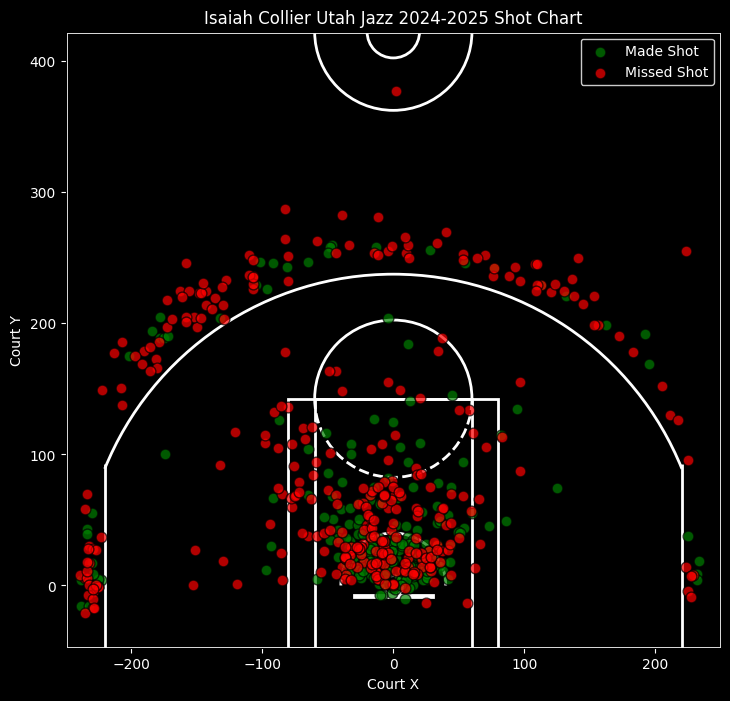

In [256]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Filtra i tiri di Isaiah Collier per Utah Jazz
df_ic = utahshot[(utahshot['TEAM_NAME'] == 'Utah Jazz') & (utahshot['PLAYER_NAME'] == 'Isaiah Collier')]

# Funzione per disegnare il campo
def draw_court(ax=None, color='white', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()
    hoop = patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer = patches.Circle((0, 422.5), radius=60, linewidth=lw, color=color, fill=False)
    center_inner = patches.Circle((0, 422.5), radius=20, linewidth=lw, color=color, fill=False)

    court_elements = [
        hoop, backboard, outer_box, inner_box, top_free_throw, bottom_free_throw,
        restricted, corner_three_a, corner_three_b, three_arc, center_outer, center_inner
    ]

    for element in court_elements:
        ax.add_patch(element)

    if outer_lines:
        outer_lines_box = patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        ax.add_patch(outer_lines_box)

    return ax

made_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 1]
missed_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 0]

fig, ax = plt.subplots(figsize=(9, 8))
# Sfondo nero figura e area grafico
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax = draw_court(ax, outer_lines=True)  # linee bianche per contrasto

# Scatter plot tiri segnati e sbagliati
ax.scatter(made_shots['LOC_X'], made_shots['LOC_Y'], c='green', label='Made Shot', alpha=0.7, s=60, edgecolors='black')
ax.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'], c='red', label='Missed Shot', alpha=0.7, s=60, edgecolors='black')

ax.set_xlim(-250, 250)
ax.set_ylim(-47.5, 422.5)

# Titolo e etichette assi con colore bianco
ax.set_xlabel('Court X', color='white')
ax.set_ylabel('Court Y', color='white')
ax.set_title('Isaiah Collier Utah Jazz 2024-2025 Shot Chart', color='white')

# Colori assi e ticks bianchi
ax.tick_params(colors='white')

# Legenda con sfondo e testo personalizzati
legend = ax.legend(loc='upper right')
frame = legend.get_frame()
frame.set_facecolor('black')
frame.set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')

ax.set_aspect('equal')

plt.show()


**Jordan Clarkson**

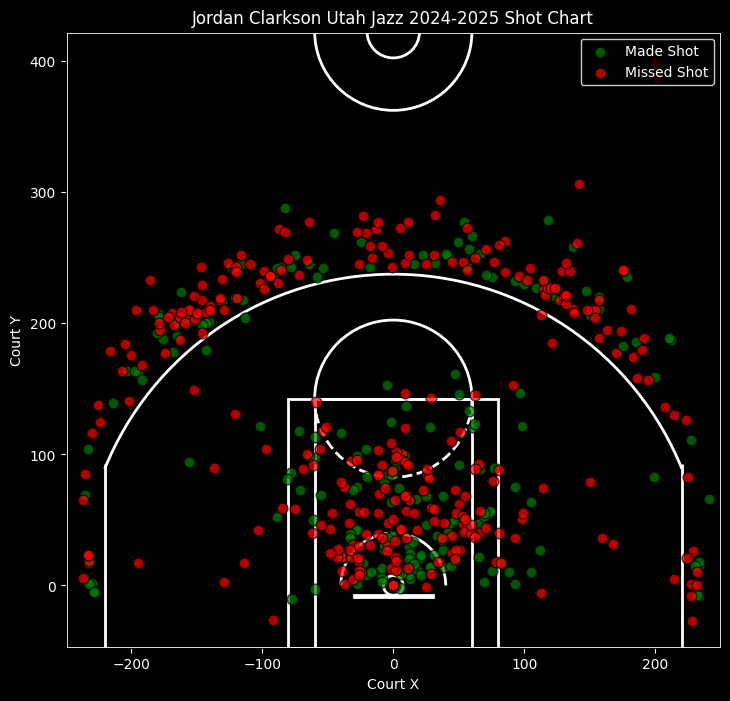

In [257]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Filtra i tiri di Isaiah Collier per Utah Jazz
df_ic = utahshot[(utahshot['TEAM_NAME'] == 'Utah Jazz') & (utahshot['PLAYER_NAME'] == 'Jordan Clarkson')]

# Funzione per disegnare il campo
def draw_court(ax=None, color='white', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()
    hoop = patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer = patches.Circle((0, 422.5), radius=60, linewidth=lw, color=color, fill=False)
    center_inner = patches.Circle((0, 422.5), radius=20, linewidth=lw, color=color, fill=False)

    court_elements = [
        hoop, backboard, outer_box, inner_box, top_free_throw, bottom_free_throw,
        restricted, corner_three_a, corner_three_b, three_arc, center_outer, center_inner
    ]

    for element in court_elements:
        ax.add_patch(element)

    if outer_lines:
        outer_lines_box = patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        ax.add_patch(outer_lines_box)

    return ax

made_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 1]
missed_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 0]

fig, ax = plt.subplots(figsize=(9, 8))
# Sfondo nero figura e area grafico
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax = draw_court(ax, outer_lines=True)  # linee bianche per contrasto

# Scatter plot tiri segnati e sbagliati
ax.scatter(made_shots['LOC_X'], made_shots['LOC_Y'], c='green', label='Made Shot', alpha=0.7, s=60, edgecolors='black')
ax.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'], c='red', label='Missed Shot', alpha=0.7, s=60, edgecolors='black')

ax.set_xlim(-250, 250)
ax.set_ylim(-47.5, 422.5)

# Titolo e etichette assi con colore bianco
ax.set_xlabel('Court X', color='white')
ax.set_ylabel('Court Y', color='white')
ax.set_title('Jordan Clarkson Utah Jazz 2024-2025 Shot Chart', color='white')

# Colori assi e ticks bianchi
ax.tick_params(colors='white')

# Legenda con sfondo e testo personalizzati
legend = ax.legend(loc='upper right')
frame = legend.get_frame()
frame.set_facecolor('black')
frame.set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')

ax.set_aspect('equal')

plt.show()


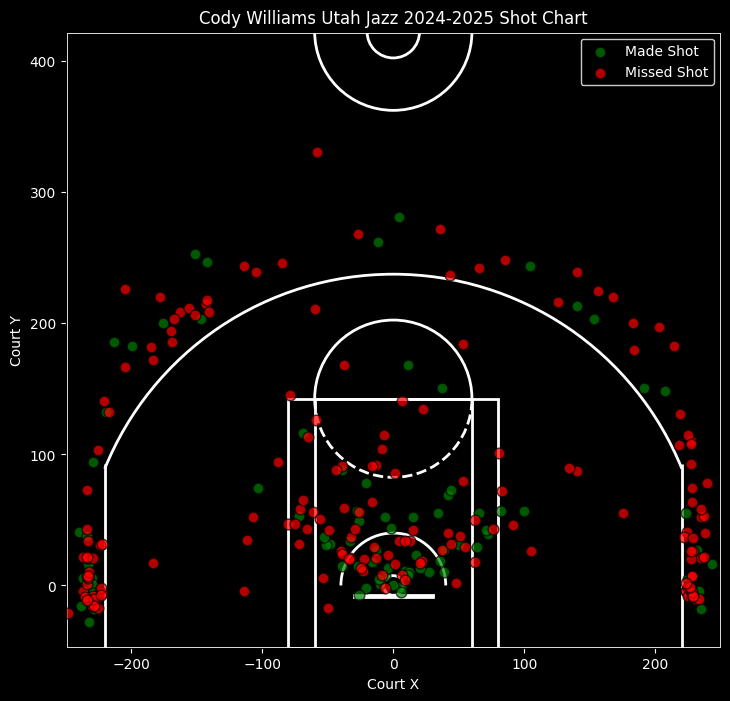

In [258]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Filtra i tiri di Isaiah Collier per Utah Jazz
df_ic = utahshot[(utahshot['TEAM_NAME'] == 'Utah Jazz') & (utahshot['PLAYER_NAME'] == 'Cody Williams')]

# Funzione per disegnare il campo
def draw_court(ax=None, color='white', lw=2, outer_lines=False):
    if ax is None:
        ax = plt.gca()
    hoop = patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    backboard = patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    outer_box = patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    top_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    bottom_free_throw = patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linewidth=lw, color=color, linestyle='dashed')
    restricted = patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    corner_three_a = patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    center_outer = patches.Circle((0, 422.5), radius=60, linewidth=lw, color=color, fill=False)
    center_inner = patches.Circle((0, 422.5), radius=20, linewidth=lw, color=color, fill=False)

    court_elements = [
        hoop, backboard, outer_box, inner_box, top_free_throw, bottom_free_throw,
        restricted, corner_three_a, corner_three_b, three_arc, center_outer, center_inner
    ]

    for element in court_elements:
        ax.add_patch(element)

    if outer_lines:
        outer_lines_box = patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False)
        ax.add_patch(outer_lines_box)

    return ax

made_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 1]
missed_shots = df_ic[df_ic['SHOT_MADE_FLAG'] == 0]

fig, ax = plt.subplots(figsize=(9, 8))
# Sfondo nero figura e area grafico
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

ax = draw_court(ax, outer_lines=True)  # linee bianche per contrasto

# Scatter plot tiri segnati e sbagliati
ax.scatter(made_shots['LOC_X'], made_shots['LOC_Y'], c='green', label='Made Shot', alpha=0.7, s=60, edgecolors='black')
ax.scatter(missed_shots['LOC_X'], missed_shots['LOC_Y'], c='red', label='Missed Shot', alpha=0.7, s=60, edgecolors='black')

ax.set_xlim(-250, 250)
ax.set_ylim(-47.5, 422.5)

# Titolo e etichette assi con colore bianco
ax.set_xlabel('Court X', color='white')
ax.set_ylabel('Court Y', color='white')
ax.set_title('Cody Williams Utah Jazz 2024-2025 Shot Chart', color='white')

# Colori assi e ticks bianchi
ax.tick_params(colors='white')

# Legenda con sfondo e testo personalizzati
legend = ax.legend(loc='upper right')
frame = legend.get_frame()
frame.set_facecolor('black')
frame.set_edgecolor('white')
for text in legend.get_texts():
    text.set_color('white')

ax.set_aspect('equal')

plt.show()


### Confronto sugli altri ruoli

Stesso confronto Jazz vs playoff applicato a SG e SF, per completare il quadro avviato con i PG.

La media punti degli SG Utah Jazz risulta più alta della media delle squadre playoff sullo stesso ruolo (10.26 vs 8.10 PTS): a differenza del playmaker, la guardia tiratrice è quindi già sopra lo standard delle squadre competitive.

In [259]:
pgutah = df.loc[df["Pos"]=="SG"]
pgpo = ppo.loc[ppo["Pos"]=="SG"]

pgutah.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SG,10.26


In [260]:
pgpo.groupby("Pos")["PTS"].mean().reset_index()

,Pos,PTS
0,SG,8.611243


**Grafico di sintesi.** I confronti punto-per-punto per PG, SG e SF viste sopra vengono qui riuniti in un unico grafico a barre raggruppate, per leggere a colpo d'occhio dove i Jazz sono sopra o sotto lo standard delle squadre playoff.

In [261]:
# Grafico di sintesi (aggiunto in fase di revisione): media punti Jazz vs squadre playoff
# per PG, SG, SF, a partire dagli stessi aggregati calcolati nelle celle precedenti.
confronto_ruoli = pd.DataFrame({
    "Pos": ["PG", "SG", "SF"],
    "Utah Jazz": [
        df.loc[df["Pos"] == "PG", "PTS"].mean(),
        df.loc[df["Pos"] == "SG", "PTS"].mean(),
        df.loc[df["Pos"] == "SF", "PTS"].mean(),
    ],
    "Squadre playoff": [
        ppo.loc[ppo["Pos"] == "PG", "PTS"].mean(),
        ppo.loc[ppo["Pos"] == "SG", "PTS"].mean(),
        ppo.loc[ppo["Pos"] == "SF", "PTS"].mean(),
    ],
})

fig = px.bar(
    confronto_ruoli,
    x="Pos",
    y=["Utah Jazz", "Squadre playoff"],
    barmode="group",
    width=800,
    height=500,
    title="Media punti per ruolo: Utah Jazz vs squadre playoff"
)

fig.update_layout(
    paper_bgcolor='black',
    plot_bgcolor='black',
    font=dict(color='white'),
    xaxis=dict(color='white'),
    yaxis=dict(color='white')
)

fig.show()


## Stipendi

Confronto tra produzione e costo: si carica la tabella stipendi 2024-25 (`allleagueplayersandsalary.csv`) e si isola la sola rosa Jazz.

In [279]:
import pandas as pd
stipendi = pd.read_csv("data/allleagueplayersandsalary.csv")

In [263]:
stipendi.head()

,Rk,Player,Age,Pos,G,GS,MP,FG,FGA,FG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Team,Salary
0,1,Donovan Mitchell,28,SG,71,71.0,31.4,8.2,18.6,0.443,...,3.7,4.5,5.0,1.3,0.2,2.1,2.0,24.0,Cleveland Cavaliers,"35,410,310"
1,2,Darius Garland,25,PG,75,75.0,30.7,7.4,15.7,0.472,...,2.2,2.9,6.7,1.2,0.1,2.5,1.9,20.6,Cleveland Cavaliers,"36,725,670"
2,3,Evan Mobley,23,PF,71,71.0,30.5,7.1,12.8,0.557,...,7.0,9.3,3.2,0.9,1.6,2.0,2.0,18.5,Cleveland Cavaliers,"11,227,657"
3,4,Jarrett Allen,26,C,82,82.0,28.0,5.5,7.8,0.706,...,7.1,9.7,1.9,0.9,0.9,1.2,1.5,13.5,Cleveland Cavaliers,"20,000,000"
4,5,Max Strus,28,SF,50,37.0,25.5,3.3,7.5,0.442,...,3.3,4.3,3.2,0.5,0.2,1.1,2.1,9.4,Cleveland Cavaliers,"15,212,068"


In [ ]:
stipendiutah = stipendi.loc[stipendi["Team"]=="Utah Jazz"]

In [265]:
stipendiutah

,Rk,Player,Age,Pos,G,GS,MP,FG,FGA,FG%,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Team,Salary


**Nota sui dati salariali**: la tabella stipendi non copre l'intero roster. Risultano mancanti Micah Potter, Oscar Tshiebwe, Elijah Harkless, Patty Mills e Drew Eubanks; Omer Yurtseven e Darius Bazley, presenti nella fonte salariale ma non nel roster attivo analizzato, sono stati esclusi.

In [266]:
df

,Player,Pos,Height,Weight,Birth_Date,Age,Exp,G,GS,MP,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,Jordan Clarkson,SG,6'3,194,1992-06-07,32,10,37,9,26.0,...,0.797,0.7,2.5,3.2,3.7,0.8,0.2,2.3,1.4,16.2
1,Isaiah Collier,PG,6'3,210,2004-10-08,20,R,71,46,25.9,...,0.682,0.5,2.9,3.3,6.3,0.9,0.2,2.9,2.1,8.7
2,John Collins,PF,6'9,235,1997-09-23,27,7,40,31,30.5,...,0.848,2.2,6.0,8.2,2.0,1.0,1.0,2.6,2.9,19.0
3,Drew Eubanks,C,6'9,245,1997-02-01,27,6,37,4,15.4,...,0.632,1.1,3.5,4.5,1.2,0.3,0.9,0.8,1.2,5.8
4,Kyle Filipowski,C,6'11,250,2003-11-07,21,R,72,27,21.1,...,0.650,1.6,4.6,6.1,1.9,0.7,0.3,1.4,2.4,9.6
5,Keyonte George,PG,6'4,185,2003-11-08,21,1,67,35,31.5,...,0.818,0.4,3.4,3.8,5.6,0.7,0.1,2.7,1.7,16.8
6,Elijah Harkless,SG,6'3,195,2000-02-03,24,R,10,0,13.8,...,0.500,0.9,1.2,2.1,0.8,1.0,0.1,0.3,1.8,3.2
7,Taylor Hendricks,PF,6'9,210,2003-11-22,21,1,3,3,25.0,...,0.750,1.7,3.3,5.0,0.7,1.7,1.3,0.7,2.7,4.7
8,Johnny Juzang,SG,6'7,215,2001-03-17,23,2,64,18,19.8,...,0.849,0.7,2.2,2.9,1.1,0.6,0.1,0.6,2.0,8.9
9,Walker Kessler,C,7'0,245,2001-07-26,23,2,58,58,30.0,...,0.520,4.6,7.6,12.2,1.7,0.6,2.4,1.5,2.2,11.1


**Media punti degli SG delle squadre che hanno giocato i playoff** (stesso dato di cella 78, richiamato qui per confronto diretto col valore Jazz sopra).

## Peso offensivo e difensivo di ogni giocatore

Si normalizzano (Min-Max) punti, assist, palle rubate e stoppate e si combinano in due indici sintetici — peso offensivo e peso difensivo — per ottenere una prima classifica di impatto complessivo, indipendente dal ruolo.

In [267]:
from sklearn.preprocessing import MinMaxScaler
dfa = df.copy()
scaler = MinMaxScaler()
dfa[["PTS_n", "AST_n", "STL_n", "BLK_n"]] = scaler.fit_transform(dfa[["PTS", "AST", "STL", "BLK"]])

In [268]:
dfa["Offensive_Weight"] = (0.7 * dfa["PTS_n"]) + (0.3 * dfa["AST_n"])
dfa["Defensive_Weight"] = (0.6 * dfa["BLK_n"]) + (0.4 * dfa["STL_n"])

In [269]:
dfa.head()

,Player,Pos,Height,Weight,Birth_Date,Age,Exp,G,GS,MP,...,BLK,TOV,PF,PTS,PTS_n,AST_n,STL_n,BLK_n,Offensive_Weight,Defensive_Weight
0,Jordan Clarkson,SG,6'3,194,1992-06-07,32,10,37,9,26.0,...,0.2,2.3,1.4,16.2,0.822785,0.543860,0.357143,0.043478,0.739107,0.168944
1,Isaiah Collier,PG,6'3,210,2004-10-08,20,R,71,46,25.9,...,0.2,2.9,2.1,8.7,0.348101,1.000000,0.428571,0.043478,0.543671,0.197516
2,John Collins,PF,6'9,235,1997-09-23,27,7,40,31,30.5,...,1.0,2.6,2.9,19.0,1.000000,0.245614,0.500000,0.391304,0.773684,0.434783
3,Drew Eubanks,C,6'9,245,1997-02-01,27,6,37,4,15.4,...,0.9,0.8,1.2,5.8,0.164557,0.105263,0.000000,0.347826,0.146769,0.208696
4,Kyle Filipowski,C,6'11,250,2003-11-07,21,R,72,27,21.1,...,0.3,1.4,2.4,9.6,0.405063,0.228070,0.285714,0.086957,0.351965,0.166460


In [270]:
dfa["Total_Impact"] = dfa["Offensive_Weight"] + dfa["Defensive_Weight"]
dfa.sort_values("Total_Impact", ascending=False)[["Player", "Pos", "Offensive_Weight", "Defensive_Weight", "Total_Impact"]]

,Player,Pos,Offensive_Weight,Defensive_Weight,Total_Impact
2,John Collins,PF,0.773684,0.434783,1.208467
9,Walker Kessler,C,0.407895,0.685714,1.093609
5,Keyonte George,PG,0.865690,0.114286,0.979975
16,Collin Sexton,SG,0.862891,0.114286,0.977177
10,Lauri Markkanen,PF,0.747368,0.192547,0.939915
0,Jordan Clarkson,SG,0.739107,0.168944,0.908051
7,Taylor Hendricks,PF,0.071719,0.713043,0.784762
1,Isaiah Collier,PG,0.543671,0.197516,0.741186
4,Kyle Filipowski,C,0.351965,0.166460,0.518425
15,Brice Sensabaugh,SF,0.388508,0.085714,0.474222


### Clustering

A partire dai due indici di impatto si applica un K-Means per raggruppare i giocatori in cluster omogenei di profilo offensivo/difensivo, come base per la successiva segmentazione in fasce di rotazione.

In [271]:
from sklearn.cluster import KMeans

In [272]:
X = dfa[["Offensive_Weight", "Defensive_Weight", "Total_Impact"]]
kmeans = KMeans(n_clusters=3, random_state=42)
dfa["Cluster"] = kmeans.fit_predict(X)

c:\Users\ary20\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\ary20\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ary20\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ary20\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ar

In [273]:
dfa[["Player", "Pos", "Offensive_Weight", "Defensive_Weight", "Total_Impact", "Cluster"]].sort_values("Cluster", ascending=True)

,Player,Pos,Offensive_Weight,Defensive_Weight,Total_Impact,Cluster
7,Taylor Hendricks,PF,0.071719,0.713043,0.784762,0
9,Walker Kessler,C,0.407895,0.685714,1.093609,0
4,Kyle Filipowski,C,0.351965,0.166460,0.518425,1
3,Drew Eubanks,C,0.146769,0.208696,0.355464,1
12,Patty Mills,PG,0.084744,0.140373,0.225116,1
11,KJ Martin,SF,0.184710,0.052174,0.236884,1
8,Johnny Juzang,SG,0.278847,0.085714,0.364562,1
6,Elijah Harkless,SG,0.010526,0.200000,0.210526,1
14,Micah Potter,C,0.059260,0.106832,0.166093,1
13,Svi Mykhailiuk,SF,0.321785,0.083230,0.405015,1


**2. Core 6** — i giocatori che decidono le partite

0. **Rotation** — contributori reali dalla panchina, più qualche giovane in crescita
1. **End-of-bench** — sviluppo, two-way, garbage time

## Player Analysis

Ogni giocatore del roster viene profilato individualmente: ruolo offensivo stimato, punteggio di impatto (tier), giocatori comparabili per cluster e radar chart delle sei dimensioni di gioco (scoring, efficienza, playmaking, tiro, difesa, rimbalzi).

Il modulo `nba_player_analysis.py`, incollato nella cella seguente, implementa l'intera pipeline di profilazione:

* **normalizzazione del ruolo** e benchmark posizionali di riferimento (`NBA_BENCH`) su MP, PTS, AST, TRB, STL, BLK, TOV e percentuali di tiro;
* **metriche stimate** — usage rate, AST%, true shooting, punteggio di impatto difensivo, playmaking score — calcolate dalle statistiche box-score disponibili;
* **clustering K-Means** in 5 archetipi di gioco (`ARCHETYPE_NAMES`) e ricerca dei giocatori comparabili per profilo;
* **tier di valutazione** (`TIER_LABELS`), dal Franchise Cornerstone al Non-Roster/Trade Candidate;
* **radar chart** per giocatore sulle sei dimensioni di gioco, salvato su file;
* generazione di un **report testuale per giocatore** più un report aggregato sull'intero roster.

La cella successiva esegue `run_analysis(df)` sul roster Jazz.

In [274]:
"""
NBA Individual Player Analysis Report Generator — 2024-25
==========================================================
Utilizza il dataframe `df` con le colonne standard Basketball-Reference.
Lancia questo script DOPO aver caricato `df` nel tuo ambiente Python.

Output:
  - Una cartella `player_reports/` con un .txt per giocatore
  - Un file `player_reports/_FULL_ROSTER_REPORT.txt` con tutti i giocatori

Dipendenze:
    pip install pandas numpy matplotlib scikit-learn scipy
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy.stats import norm as scipy_norm
import os
import re

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURAZIONE
# ─────────────────────────────────────────────────────────────────────────────

OUTPUT_DIR  = "player_reports"
SAVE_RADAR  = True   # Salva radar chart PNG nella cartella output
N_CLUSTERS  = 5      # Numero cluster K-Means (ridotto automaticamente se roster < 5)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# BENCHMARK NBA PER RUOLO — 2024-25 (media, std)
# ─────────────────────────────────────────────────────────────────────────────

NBA_BENCH = {
    "PG": {
        "MP":  (28.5, 6.0),  "PTS": (14.2, 5.8),  "AST": (5.8, 2.4),
        "TRB": (4.1,  1.8),  "STL": (1.2,  0.40), "BLK": (0.3, 0.20),
        "TOV": (2.4,  0.90), "FG%": (0.445,0.045), "3P%": (0.355,0.045),
        "eFG%":(0.520,0.048),"FT%": (0.815,0.060), "3PA": (6.2, 2.8),
        "FGA": (13.1, 4.0),  "AST_PCT": (28.5, 8.0),
    },
    "SG": {
        "MP":  (27.0, 6.5),  "PTS": (13.8, 5.5),  "AST": (3.2, 1.6),
        "TRB": (3.8,  1.6),  "STL": (0.9,  0.35), "BLK": (0.4, 0.25),
        "TOV": (1.8,  0.70), "FG%": (0.448,0.048), "3P%": (0.360,0.050),
        "eFG%":(0.528,0.050),"FT%": (0.820,0.060), "3PA": (5.5, 2.5),
        "FGA": (12.5, 4.2),  "AST_PCT": (15.0, 5.5),
    },
    "SF": {
        "MP":  (27.5, 6.0),  "PTS": (13.5, 5.2),  "AST": (2.8, 1.4),
        "TRB": (5.2,  2.0),  "STL": (0.9,  0.35), "BLK": (0.6, 0.35),
        "TOV": (1.7,  0.65), "FG%": (0.462,0.050), "3P%": (0.355,0.055),
        "eFG%":(0.535,0.052),"FT%": (0.790,0.070), "3PA": (4.8, 2.4),
        "FGA": (11.8, 3.8),  "AST_PCT": (13.5, 5.0),
    },
    "PF": {
        "MP":  (26.5, 6.5),  "PTS": (12.8, 5.0),  "AST": (2.2, 1.3),
        "TRB": (6.8,  2.5),  "STL": (0.8,  0.30), "BLK": (0.9, 0.50),
        "TOV": (1.6,  0.65), "FG%": (0.490,0.060), "3P%": (0.340,0.070),
        "eFG%":(0.545,0.058),"FT%": (0.760,0.080), "3PA": (3.2, 2.2),
        "FGA": (10.8, 3.5),  "AST_PCT": (11.0, 4.5),
    },
    "C": {
        "MP":  (25.0, 7.0),  "PTS": (12.0, 5.5),  "AST": (1.8, 1.0),
        "TRB": (8.5,  2.8),  "STL": (0.7,  0.28), "BLK": (1.4, 0.70),
        "TOV": (1.6,  0.70), "FG%": (0.555,0.065), "3P%": (0.310,0.090),
        "eFG%":(0.562,0.065),"FT%": (0.720,0.090), "3PA": (1.5, 1.5),
        "FGA": (9.5,  3.5),  "AST_PCT": (9.5,  4.0),
    },
}

ARCHETYPE_NAMES = {
    0: "Two-Way Versatile",
    1: "Off-Ball 3PT Specialist",
    2: "Primary Ball Handler",
    3: "Interior Force",
    4: "Secondary Playmaker / Scorer",
}

TIER_LABELS = [
    (85, "Franchise Cornerstone"),
    (70, "High-Value Starter"),
    (55, "Rotation Positive Asset"),
    (40, "Serviceable Rotation"),
    (25, "Developmental Asset"),
    (0,  "Non-Roster / Trade Candidate"),
]

# ─────────────────────────────────────────────────────────────────────────────
# UTILITY
# ─────────────────────────────────────────────────────────────────────────────

def normalize_pos(pos: str) -> str:
    pos = str(pos).upper().split("-")[0].strip()
    mapping = {
        "PG": "PG", "SG": "SG", "SF": "SF", "PF": "PF", "C": "C",
        "G": "SG", "F": "SF", "G-F": "SF", "F-C": "PF", "C-F": "PF",
    }
    return mapping.get(pos, "SF")


def pct(value, mean, std, higher_is_better=True):
    if std <= 0:
        return 50.0
    z = (value - mean) / std
    p = scipy_norm.cdf(z) * 100
    return p if higher_is_better else (100 - p)


def pct_label(p):
    if p >= 85: return "Elite"
    if p >= 68: return "Above Avg"
    if p >= 45: return "Average"
    if p >= 25: return "Below Avg"
    return "Low"


def usage_est(pts, fga, fta, mp, team_pace=100.0):
    if mp <= 0:
        return 0.0
    poss  = fga + 0.44 * fta
    avail = (mp / 48.0) * team_pace
    return min(poss / avail * 100, 45.0) if avail > 0 else 0.0


def ast_pct_est(ast, mp, pts_team=110.0):
    if mp <= 0:
        return 0.0
    fg_per_min = pts_team / 48.0 / 2.1
    return min(ast / max(mp / 48.0 * fg_per_min, 0.01) * 100, 60.0)


def true_shooting(pts, fga, fta):
    denom = 2.0 * (fga + 0.44 * fta)
    return pts / denom if denom > 0 else 0.0


def def_impact_score(stl, blk, drb, pos):
    base = {
        "PG": (1.2, 0.3, 2.8), "SG": (0.9, 0.4, 2.6),
        "SF": (0.9, 0.6, 3.4), "PF": (0.8, 0.9, 4.8), "C": (0.7, 1.4, 6.0),
    }
    bstl, bblk, bdrb = base.get(pos, (0.9, 0.6, 3.5))
    score = (
        0.40 * min(stl / max(bstl, 0.01), 2.0) +
        0.35 * min(blk / max(bblk, 0.01), 2.0) +
        0.25 * min(drb / max(bdrb, 0.01), 2.0)
    )
    return min(score * 50.0, 100.0)


def playmaking_score(ast, tov, mp):
    if mp <= 0:
        return 0.0
    net_per36 = (ast - tov * 0.5) / mp * 36
    return min(max(net_per36 * 10.0, 0.0), 100.0)


def get_tier(score):
    for threshold, label in TIER_LABELS:
        if score >= threshold:
            return label
    return TIER_LABELS[-1][1]


def off_role(usage, ast_pct, pts):
    if usage >= 28 and pts >= 20:      return "Primary Scorer / 1st Option"
    if usage >= 22 and ast_pct >= 22:  return "Shot Creator / Playmaker"
    if usage >= 22:                    return "Secondary Scorer"
    if ast_pct >= 22:                  return "Primary Distributor"
    if ast_pct >= 15:                  return "Secondary Playmaker"
    return "Off-Ball Role Player / Specialist"


def parse_exp(exp_str):
    s = str(exp_str).strip().upper()
    if s == "R":
        return 0
    try:
        return int(s)
    except ValueError:
        return 5

# ─────────────────────────────────────────────────────────────────────────────
# CLUSTERING
# ─────────────────────────────────────────────────────────────────────────────

def build_cluster_features(df):
    rows = []
    for _, r in df.iterrows():
        pos = normalize_pos(r["Pos"])
        u   = usage_est(r["PTS"], r["FGA"], r["FTA"], r["MP"])
        ap  = ast_pct_est(r["AST"], r["MP"])
        ds  = def_impact_score(r["STL"], r["BLK"], r["DRB"], pos)
        rows.append({
            "usage":    u,
            "efg":      r["eFG%"],
            "ast_pct":  ap,
            "3pa_rate": r["3PA"] / max(r["FGA"], 0.01),
            "def":      ds / 100.0,
        })
    return pd.DataFrame(rows)


def run_clustering(df, n_clusters=N_CLUSTERS):
    feat_df = build_cluster_features(df)
    scaler  = StandardScaler()
    X       = scaler.fit_transform(feat_df)
    k       = min(n_clusters, len(df))
    km      = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels  = km.fit_predict(X)
    dist    = cdist(X, km.cluster_centers_, metric="euclidean")
    cdist_  = dist[np.arange(len(X)), labels]
    max_d   = cdist_.max() if cdist_.max() > 0 else 1.0
    sim     = 1.0 - cdist_ / max_d
    return labels, sim


def comparable_players(idx, labels, sim, df, n=3):
    cl   = labels[idx]
    same = [(i, sim[i]) for i in range(len(labels)) if labels[i] == cl and i != idx]
    same.sort(key=lambda x: x[1], reverse=True)
    return [(df.iloc[i]["Player"], round(s, 2)) for i, s in same[:n]]

# ─────────────────────────────────────────────────────────────────────────────
# RADAR CHART
# ─────────────────────────────────────────────────────────────────────────────

def _norm_radar(val, mean, std, clip=2.5):
    z = (val - mean) / max(std, 0.01)
    return float(min(max((z / clip + 1.0) / 2.0, 0.0), 1.0))


def player_radar_vals(r, pos):
    b  = NBA_BENCH.get(pos, NBA_BENCH["SF"])
    tp = r["3P%"] if r["3PA"] > 0.3 else b["3P%"][0]
    return {
        "scoring":    _norm_radar(r["PTS"],           b["PTS"][0],  b["PTS"][1]),
        "efficiency": _norm_radar(r["eFG%"],           b["eFG%"][0], b["eFG%"][1]),
        "playmaking": _norm_radar(r["AST"],            b["AST"][0],  b["AST"][1]),
        "shooting":   _norm_radar(tp,                  b["3P%"][0],  b["3P%"][1]),
        "defense":    _norm_radar(r["STL"] + r["BLK"],
                                  b["STL"][0] + b["BLK"][0],
                                  b["STL"][1] + b["BLK"][1]),
        "rebounding": _norm_radar(r["TRB"],            b["TRB"][0],  b["TRB"][1]),
    }


def save_radar(player_name, pvals, save_path):
    CATS   = ["Scoring\nVolume", "Efficiency", "Playmaking",
              "Shooting", "Defense", "Rebounding"]
    KEYS   = ["scoring", "efficiency", "playmaking", "shooting", "defense", "rebounding"]
    N      = len(CATS)
    angles = [n / N * 2 * np.pi for n in range(N)] + [0]

    def vlist(d):
        v = [d.get(k, 0) for k in KEYS]
        return v + [v[0]]

    role_avg    = {k: 0.50 for k in KEYS}
    starter_avg = {k: 0.58 for k in KEYS}

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(CATS, color="#aaaaaa", fontsize=9, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25", "50", "75", "100"], color="#555555", fontsize=7)
    ax.grid(color="#333333", linewidth=0.8)
    ax.spines["polar"].set_color("#333333")

    for data, color, label, lw, ls in [
        (starter_avg, "#555555", "NBA Starter Avg", 1.5, "--"),
        (role_avg,    "#f0a500", "Role Avg",         1.8, ":"),
        (pvals,       "#00bfff", player_name,         2.5, "-"),
    ]:
        v = vlist(data)
        ax.plot(angles, v, color=color, linewidth=lw, linestyle=ls, label=label)
        alpha = 0.25 if data is pvals else 0.15
        ax.fill(angles, v, color=color, alpha=alpha)

    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15),
              framealpha=0.0, labelcolor="#cccccc", fontsize=8)
    ax.set_title(f"{player_name} — Radar Profile",
                 color="white", fontsize=11, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight", facecolor="#0d1117")
    plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# PLAYER IMPACT SCORE
# ─────────────────────────────────────────────────────────────────────────────

def compute_impact(r, pos):
    b    = NBA_BENCH.get(pos, NBA_BENCH["SF"])
    eff  = pct(r["eFG%"], b["eFG%"][0], b["eFG%"][1]) / 100.0
    ts   = true_shooting(r["PTS"], r["FGA"], r["FTA"])
    ts_p = pct(ts, 0.540, 0.055) / 100.0
    efficiency = eff * 0.6 + ts_p * 0.4

    vol  = pct(r["PTS"], b["PTS"][0], b["PTS"][1]) / 100.0
    sust = efficiency * 0.5 + vol * 0.5

    def_s = def_impact_score(r["STL"], r["BLK"], r["DRB"], pos) / 100.0
    pm    = playmaking_score(r["AST"], r["TOV"], r["MP"]) / 100.0
    reb   = pct(r["TRB"], b["TRB"][0], b["TRB"][1]) / 100.0

    score = (
        0.30 * efficiency * 100 +
        0.25 * sust       * 100 +
        0.15 * def_s      * 100 +
        0.15 * pm         * 100 +
        0.15 * reb        * 100
    )
    return round(min(max(score, 0.0), 100.0), 1)


def impact_components(r, pos):
    b    = NBA_BENCH.get(pos, NBA_BENCH["SF"])
    eff  = pct(r["eFG%"], b["eFG%"][0], b["eFG%"][1]) / 100.0
    ts   = true_shooting(r["PTS"], r["FGA"], r["FTA"])
    ts_p = pct(ts, 0.540, 0.055) / 100.0
    efficiency = eff * 0.6 + ts_p * 0.4

    vol  = pct(r["PTS"], b["PTS"][0], b["PTS"][1]) / 100.0
    sust = efficiency * 0.5 + vol * 0.5
    def_s = def_impact_score(r["STL"], r["BLK"], r["DRB"], pos) / 100.0
    pm   = playmaking_score(r["AST"], r["TOV"], r["MP"]) / 100.0
    reb  = pct(r["TRB"], b["TRB"][0], b["TRB"][1]) / 100.0

    return {
        "efficiency": round(0.30 * efficiency * 100, 1),
        "scoring":    round(0.25 * sust       * 100, 1),
        "defense":    round(0.15 * def_s      * 100, 1),
        "playmaking": round(0.15 * pm         * 100, 1),
        "rebounding": round(0.15 * reb        * 100, 1),
    }

# ─────────────────────────────────────────────────────────────────────────────
# STRATEGIC DECISION
# ─────────────────────────────────────────────────────────────────────────────

def strategic_decision(impact, age, exp):
    if impact >= 70 and age <= 28:
        return ("CORE — Intoccabile",
                "Finestra competitiva: 3-5 anni",
                "Asset di primo piano, valore contrattuale alto")
    if impact >= 55 and age <= 30:
        return ("CORE / STARTER Confermato",
                "Contributo immediato, fit verificato",
                "Asset solido, difficile da sostituire a breve")
    if impact >= 40:
        return ("ROTATION — Valutare rinnovo",
                "Contributo nel breve periodo, monitorare crescita",
                "Trade bait potenziale in package deal")
    if age <= 23 and exp <= 3:
        return ("DEVELOPMENT — Progetto da coltivare",
                "Orizzonte di sviluppo: 2-3 anni",
                "Valore futuro superiore a quello attuale")
    return ("TRADE / WAIVE — Ottimizzazione roster",
            "Fit discutibile con la direzione della squadra",
            "Liberare cap space o inserire in scambio")

# ─────────────────────────────────────────────────────────────────────────────
# REPORT BUILDER
# ─────────────────────────────────────────────────────────────────────────────

SEP  = "=" * 65
SEP2 = "-" * 65


def build_report(r, df, idx, labels, sim):

    name    = r["Player"]
    pos_raw = str(r["Pos"])
    pos     = normalize_pos(pos_raw)
    age     = int(r["Age"])
    exp     = parse_exp(r["Exp"])
    g       = int(r["G"])
    gs      = int(r["GS"])
    mp      = float(r["MP"])
    pts     = float(r["PTS"])
    ast     = float(r["AST"])
    trb     = float(r["TRB"])
    drb     = float(r["DRB"])
    stl     = float(r["STL"])
    blk     = float(r["BLK"])
    tov     = float(r["TOV"])
    fga     = float(r["FGA"])
    fta     = float(r["FTA"])
    fg_pct  = float(r["FG%"])
    efg     = float(r["eFG%"])
    three_p  = float(r["3P%"])
    three_pa = float(r["3PA"])
    ft_pct  = float(r["FT%"])

    b = NBA_BENCH.get(pos, NBA_BENCH["SF"])

    # Metriche derivate
    u        = usage_est(pts, fga, fta, mp)
    ast_pct  = ast_pct_est(ast, mp)
    ts       = true_shooting(pts, fga, fta)
    ds       = def_impact_score(stl, blk, drb, pos)
    role     = off_role(u, ast_pct, pts)
    impact   = compute_impact(r, pos)
    tier     = get_tier(impact)
    comps_sc = impact_components(r, pos)
    arch_n   = ARCHETYPE_NAMES.get(int(labels[idx]) % len(ARCHETYPE_NAMES),
                                    f"Cluster {labels[idx]}")
    sim_sc   = round(float(sim[idx]), 2)
    comps_p  = comparable_players(idx, labels, sim, df)
    strat    = strategic_decision(impact, age, exp)

    # Percentili
    pct_mp  = pct(mp,      b["MP"][0],      b["MP"][1])
    pct_u   = pct(u,       20.0,  6.0)
    pct_efg = pct(efg,     b["eFG%"][0],    b["eFG%"][1])
    pct_ts  = pct(ts,      0.540, 0.055)
    pct_3p  = pct(three_p, b["3P%"][0],     b["3P%"][1]) if three_pa > 0.3 else 50.0
    pct_fg  = pct(fg_pct,  b["FG%"][0],     b["FG%"][1])
    pct_ft  = pct(ft_pct,  b["FT%"][0],     b["FT%"][1])
    pct_ast = pct(ast_pct, b["AST_PCT"][0], b["AST_PCT"][1])
    pct_def = pct(ds,      50.0,  20.0)
    pct_tov = pct(tov,     b["TOV"][0],     b["TOV"][1], higher_is_better=False)
    pct_reb = pct(trb,     b["TRB"][0],     b["TRB"][1])

    lines = []
    A = lines.append

    # ── HEADER ──
    A(SEP)
    A(f"  NBA PLAYER ANALYSIS — 2024-25 SEASON")
    A(f"  {name.upper()}  |  {pos_raw}  |  Eta: {age}  |  Exp: {r['Exp']}")
    A(SEP)
    A("")

    # ── 1. PROFILO & RUOLO ──
    A("1.  PROFILO & RUOLO NEL SISTEMA")
    A(SEP2)
    A(f"  Eta               : {age} anni")
    A(f"  Minuti/G          : {mp:.1f}  (Partite: {g}  |  GS: {gs})")
    A(f"  Usage% (stima)    : {u:.1f}%")
    A(f"  Ruolo offensivo   : {role}")
    A(f"  Percentile MP  vs {pos:<2} : {pct_mp:.0f}  ({pct_label(pct_mp)})")
    A(f"  Percentile USG vs {pos:<2} : {pct_u:.0f}  ({pct_label(pct_u)})")
    A("")
    A("  INSIGHT:")
    A(f"  Giocatore con utilizzo al {pct_u:.0f}o percentile tra i {pos} NBA,")
    A(f"  impiegato come {role.lower()}.")
    A(f"  Minutaggio al {pct_mp:.0f}o percentile di ruolo ({pct_label(pct_mp).lower()}),")
    A(f"  carico offensivo {pct_label(pct_u).lower()} rispetto alla media di ruolo.")
    A("")

    # ── 2. EFFICIENZA & SHOT PROFILE ──
    A("2.  EFFICIENZA & SHOT PROFILE")
    A(SEP2)
    CW = 24

    def row_fmt(label, val_str, p):
        lbl = pct_label(p)
        return f"  {label:<{CW}} {val_str:>8}  {p:>7.0f}     {lbl:>10}"

    A(f"  {'METRICA':<{CW}} {'VALORE':>8}  {'PCT':>7}     {'LABEL':>10}")
    A(f"  {'-'*CW} {'-'*8}  {'-'*7}     {'-'*10}")
    A(row_fmt("eFG%",        f"{efg*100:.1f}%",       pct_efg))
    A(row_fmt("TS%",         f"{ts*100:.1f}%",        pct_ts))
    A(row_fmt("3P%",         f"{three_p*100:.1f}%" if three_pa > 0.3 else "N/A",
                              pct_3p))
    A(row_fmt("FG%",         f"{fg_pct*100:.1f}%",    pct_fg))
    A(row_fmt("FT%",         f"{ft_pct*100:.1f}%",    pct_ft))
    A(row_fmt("AST%",        f"{ast_pct:.1f}%",       pct_ast))
    A(row_fmt("DEF Impact",  f"{ds:.0f}/100",         pct_def))
    A(row_fmt("TOV/G",       f"{tov:.1f}",            pct_tov))
    A("")

    overperformer = pct_efg >= 70 and u >= 20
    in_line       = 45 <= pct_efg < 70
    sustainable   = u <= 28 or (u > 28 and pct_efg >= 55)

    A("  EFFICIENZA:")
    if overperformer:
        A("  OVERPERFORMER - Alta efficienza abbinata a volume significativo.")
    elif in_line:
        A("  IN LINEA - Efficienza nella media del ruolo.")
    else:
        A("  UNDERPERFORMER - Efficienza sotto la media di ruolo.")
    A(f"  Volume sostenibile: {'SI' if sustainable else 'DA MONITORARE'}")
    A("")

    # ── 3. RADAR CHART ──
    A("3.  RADAR CHART COMPARATIVO")
    A(SEP2)

    pvals = player_radar_vals(r, pos)

    if SAVE_RADAR:
        safe  = re.sub(r'[^\w\s-]', '', name).strip().replace(' ', '_')
        rpath = os.path.join(OUTPUT_DIR, f"{safe}_radar.png")
        try:
            save_radar(name, pvals, rpath)
            A(f"  [Radar Chart salvato in: {rpath}]")
        except Exception as e:
            A(f"  [Radar non generato: {e}]")
    A("")

    KEYS_LABEL = {
        "scoring": "Scoring Volume", "efficiency": "Efficiency",
        "playmaking": "Playmaking",  "shooting": "Shooting",
        "defense": "Defense",        "rebounding": "Rebounding",
    }
    sorted_dims = sorted(pvals.items(), key=lambda x: x[1], reverse=True)
    top = [KEYS_LABEL[k] for k, v in sorted_dims[:2] if v >= 0.55]
    low = [KEYS_LABEL[k] for k, v in sorted_dims[-2:] if v <= 0.45]

    radar_txt = "  Profilo:"
    if top: radar_txt += f" sopra media per {', '.join(top)}"
    if low: radar_txt += f"{'; ' if top else ' '}sotto media per {', '.join(low)}"
    radar_txt += "."
    A(radar_txt)
    A("")

    # ── 4. PLAYER ARCHETYPE ──
    A("4.  PLAYER ARCHETYPE (Clustering K-Means)")
    A(SEP2)
    A(f"  Cluster {labels[idx]} - {arch_n}")
    A(f"  Similarita con profilo medio cluster : {sim_sc:.2f} / 1.00")
    A("  Giocatori comparabili nel roster:")
    if comps_p:
        for cname, csim in comps_p:
            A(f"    - {cname}  (sim: {csim:.2f})")
    else:
        A("    - Nessun comparabile nel roster (cluster singolo)")
    A("")

    # ── 5. PLAYER IMPACT SCORE ──
    A("5.  PLAYER IMPACT SCORE (Modello Proprietario)")
    A(SEP2)
    bar_n  = int(impact / 5)
    bar    = "X" * bar_n + "." * (20 - bar_n)
    A(f"  Impact Score : {impact:.0f} / 100")
    A(f"  [{bar}]")
    A(f"  Tier         : {tier}")
    A("")
    A("  Composizione:")
    A(f"    30% Efficiency       -> {comps_sc['efficiency']:.1f} pts")
    A(f"    25% Scoring/Volume   -> {comps_sc['scoring']:.1f} pts")
    A(f"    15% Defensive Impact -> {comps_sc['defense']:.1f} pts")
    A(f"    15% Playmaking       -> {comps_sc['playmaking']:.1f} pts")
    A(f"    15% Rebounding       -> {comps_sc['rebounding']:.1f} pts")
    A("")
    A(f"  {name} classificato come '{tier}' con impact score di {impact:.0f}/100.")
    A("")

    # ── 6. DECISIONE STRATEGICA ──
    A("6.  DECISIONE STRATEGICA")
    A(SEP2)
    A(f"  Decisione   : {strat[0]}")
    A(f"  Timeline    : {strat[1]}")
    A(f"  Asset Value : {strat[2]}")
    A("")
    A(SEP)
    A("")

    return "\n".join(lines)

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def run_analysis(df: pd.DataFrame):
    """
    Genera i report individuali per ogni giocatore nel DataFrame `df`.

    Parameters
    ----------
    df : pd.DataFrame
        Il roster NBA 2024-25 con le colonne Basketball-Reference standard.
        Il DataFrame deve chiamarsi `df` e contenere le colonne specificate.
    """

    df = df.copy().reset_index(drop=True)

    # Pulizia: le colonne percentuale possono avere NaN (0 tentativi)
    for col in ["FG%", "3P%", "2P%", "FT%", "eFG%"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    print(f"\n{'='*65}")
    print(f"  NBA ROSTER ANALYSIS — 2024-25")
    print(f"  Giocatori trovati: {len(df)}")
    print(f"{'='*65}\n")

    print("Clustering in corso...")
    labels, sim = run_clustering(df)
    unique, counts = np.unique(labels, return_counts=True)
    print(f"Distribuzione cluster: { {int(k): int(v) for k, v in zip(unique, counts)} }\n")

    all_texts = []

    for idx, (_, row) in enumerate(df.iterrows()):
        name = row["Player"]
        print(f"  {name} ...")

        text  = build_report(row, df, idx, labels, sim)
        safe  = re.sub(r'[^\w\s-]', '', name).strip().replace(' ', '_')
        fpath = os.path.join(OUTPUT_DIR, f"{safe}_report.txt")

        with open(fpath, "w", encoding="utf-8") as f:
            f.write(text)

        all_texts.append(text)
        print(f"    Salvato: {fpath}")

    full_path = os.path.join(OUTPUT_DIR, "_FULL_ROSTER_REPORT.txt")
    with open(full_path, "w", encoding="utf-8") as f:
        f.write("\n".join(all_texts))

    print(f"\n{'='*65}")
    print(f"  Report completo: {full_path}")
    print(f"  Report individuali in: {OUTPUT_DIR}/")
    print(f"{'='*65}\n")
    return full_path


# ─────────────────────────────────────────────────────────────────────────────
# UTILIZZO NEL TUO NOTEBOOK / SCRIPT
# ─────────────────────────────────────────────────────────────────────────────
#
#   from nba_player_analysis import run_analysis
#
#   # df e' gia' caricato nel tuo ambiente
#   run_analysis(df)
#
# ─────────────────────────────────────────────────────────────────────────────

In [275]:
run_analysis(df)


  NBA ROSTER ANALYSIS — 2024-25
  Giocatori trovati: 20

Clustering in corso...
Distribuzione cluster: {0: 7, 1: 8, 2: 1, 3: 2, 4: 2}

  Jordan Clarkson ...
    Salvato: player_reports\Jordan_Clarkson_report.txt
  Isaiah Collier ...
    Salvato: player_reports\Isaiah_Collier_report.txt
  John Collins ...
    Salvato: player_reports\John_Collins_report.txt
  Drew Eubanks ...
    Salvato: player_reports\Drew_Eubanks_report.txt
  Kyle Filipowski ...
    Salvato: player_reports\Kyle_Filipowski_report.txt
  Keyonte George ...
    Salvato: player_reports\Keyonte_George_report.txt
  Elijah Harkless ...
    Salvato: player_reports\Elijah_Harkless_report.txt
  Taylor Hendricks ...
    Salvato: player_reports\Taylor_Hendricks_report.txt
  Johnny Juzang ...
    Salvato: player_reports\Johnny_Juzang_report.txt
  Walker Kessler ...
    Salvato: player_reports\Walker_Kessler_report.txt
  Lauri Markkanen ...
    Salvato: player_reports\Lauri_Markkanen_report.txt
  KJ Martin ...
    Salvato: player_r

'player_reports\\_FULL_ROSTER_REPORT.txt'

In [276]:

from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
import os
import glob

INPUT_DIR  = "player_reports"
OUTPUT_DIR = "player_reports"
FONT_NAME  = "Calibri"

COLOR_HEADER  = RGBColor(0x1A, 0x37, 0x6B)
COLOR_SEP     = RGBColor(0xAA, 0xAA, 0xAA)
COLOR_INSIGHT = RGBColor(0x1A, 0x6B, 0x3A)
COLOR_BODY    = RGBColor(0x1A, 0x1A, 0x1A)

def is_separator(line):
    stripped = line.strip()
    return all(c in "=-" for c in stripped) and len(stripped) > 10

def is_section_header(line):
    stripped = line.strip()
    return len(stripped) > 4 and stripped[0].isdigit() and stripped[1] == "."

def is_main_header(line):
    return line.strip().startswith("NBA PLAYER ANALYSIS")

def is_player_name_line(line):
    stripped = line.strip()
    return stripped.isupper() and "|" in stripped and len(stripped) > 10

def is_insight_line(line):
    stripped = line.strip()
    return stripped.startswith("INSIGHT:") or stripped.startswith("EFFICIENZA:")

def add_paragraph(doc, text, bold=False, italic=False, font_size=10,
                  color=None, alignment=WD_ALIGN_PARAGRAPH.LEFT,
                  space_before=0, space_after=2):
    p = doc.add_paragraph()
    p.alignment = alignment
    p.paragraph_format.space_before = Pt(space_before)
    p.paragraph_format.space_after  = Pt(space_after)
    run = p.add_run(text)
    run.bold = bold
    run.italic = italic
    run.font.name = FONT_NAME
    run.font.size = Pt(font_size)
    if color:
        run.font.color.rgb = color
    return p

def add_separator(doc):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(0)
    p.paragraph_format.space_after  = Pt(2)
    run = p.add_run("─" * 60)
    run.font.name = FONT_NAME
    run.font.size = Pt(8)
    run.font.color.rgb = COLOR_SEP

def txt_to_docx(txt_path, docx_path):
    with open(txt_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    doc = Document()
    for section in doc.sections:
        section.top_margin    = Inches(1.0)
        section.bottom_margin = Inches(1.0)
        section.left_margin   = Inches(1.15)
        section.right_margin  = Inches(1.15)

    i = 0
    while i < len(lines):
        raw  = lines[i].rstrip("\n")
        text = raw.strip()
        i   += 1

        if not text:
            p = doc.add_paragraph()
            p.paragraph_format.space_after = Pt(3)
            continue
        if is_separator(text):
            add_separator(doc)
            continue
        if is_main_header(text):
            add_paragraph(doc, text, bold=True, font_size=9, color=COLOR_SEP, space_before=2, space_after=1)
            continue
        if is_player_name_line(text):
            add_paragraph(doc, text, bold=True, font_size=13, color=COLOR_HEADER, space_before=4, space_after=4)
            continue
        if is_section_header(text):
            add_separator(doc)
            add_paragraph(doc, text, bold=True, font_size=11, color=COLOR_HEADER, space_before=6, space_after=2)
            continue
        if is_insight_line(text):
            add_paragraph(doc, text, bold=True, font_size=9, color=COLOR_INSIGHT, space_before=2, space_after=1)
            continue
        if text.startswith("[") and ("X" in text or "." in text):
            add_paragraph(doc, text, bold=False, font_size=9, color=RGBColor(0x1A, 0x6B, 0x3A), space_after=1)
            continue
        if text.startswith("Impact Score") or text.startswith("Tier"):
            add_paragraph(doc, text, bold=True, font_size=10, color=COLOR_HEADER, space_after=1)
            continue
        if all(c in "- " for c in text) and len(text) > 15:
            add_paragraph(doc, text, bold=False, font_size=8, color=COLOR_SEP, space_after=0)
            continue
        if text.startswith("METRICA"):
            add_paragraph(doc, text, bold=True, font_size=8.5, color=COLOR_HEADER, space_after=0)
            continue
        if text.startswith("- "):
            add_paragraph(doc, "  " + text, bold=False, font_size=9.5, color=COLOR_BODY, space_after=1)
            continue
        if "->" in text:
            add_paragraph(doc, text, bold=False, font_size=9, color=COLOR_BODY, space_after=1)
            continue
        if "Radar Chart salvato in" in text:
            add_paragraph(doc, text, bold=False, italic=True, font_size=8.5, color=COLOR_SEP, space_after=2)
            continue
        add_paragraph(doc, text, bold=False, font_size=9.5, color=COLOR_BODY, space_after=1)

    doc.save(docx_path)

def convert_all(input_dir=INPUT_DIR, output_dir=OUTPUT_DIR):
    os.makedirs(output_dir, exist_ok=True)
    txt_files = sorted(glob.glob(os.path.join(input_dir, "*_report.txt")))

    if not txt_files:
        print(f"Nessun file *_report.txt trovato in '{input_dir}'.")
        return

    print(f"\nConversione di {len(txt_files)} file...\n")
    for txt_path in txt_files:
        basename  = os.path.splitext(os.path.basename(txt_path))[0]
        docx_path = os.path.join(output_dir, f"{basename}.docx")
        try:
            txt_to_docx(txt_path, docx_path)
            print(f"  OK  {docx_path}")
        except Exception as e:
            print(f"  ERRORE  {txt_path}: {e}")

    full_txt = os.path.join(input_dir, "_FULL_ROSTER_REPORT.txt")
    if os.path.exists(full_txt):
        full_docx = os.path.join(output_dir, "_FULL_ROSTER_REPORT.docx")
        try:
            txt_to_docx(full_txt, full_docx)
            print(f"  OK  {full_docx}")
        except Exception as e:
            print(f"  ERRORE  {full_txt}: {e}")

    print(f"\nFatto! File .docx salvati in: {output_dir}/\n")

convert_all()


Conversione di 21 file...

  OK  player_reports\Brice_Sensabaugh_report.docx
  OK  player_reports\Cody_Williams_report.docx
  OK  player_reports\Collin_Sexton_report.docx
  OK  player_reports\Drew_Eubanks_report.docx
  OK  player_reports\Elijah_Harkless_report.docx
  OK  player_reports\Isaiah_Collier_report.docx
  OK  player_reports\Jaden_Springer_report.docx
  OK  player_reports\John_Collins_report.docx
  OK  player_reports\Johnny_Juzang_report.docx
  OK  player_reports\Jordan_Clarkson_report.docx
  OK  player_reports\KJ_Martin_report.docx
  OK  player_reports\Keyonte_George_report.docx
  OK  player_reports\Kyle_Filipowski_report.docx
  OK  player_reports\Lauri_Markkanen_report.docx
  OK  player_reports\Micah_Potter_report.docx
  OK  player_reports\Oscar_Tshiebwe_report.docx
  OK  player_reports\Patty_Mills_report.docx
  OK  player_reports\Svi_Mykhailiuk_report.docx
  OK  player_reports\Taylor_Hendricks_report.docx
  OK  player_reports\Walker_Kessler_report.docx
  OK  player_reports\

## Decision-support model v4

Modello di supporto alla decisione per la ricostruzione del roster — corrisponde al **Capitolo 3** della tesi (*Modello Decisionale*). Cinque classi cooperano per generare le raccomandazioni di mercato:

1. `EnhancedPlayerRanker` — ranking dei giocatori su scoring, playmaking, difesa ed efficienza;
2. `EnhancedTradeabilityRanker` — stima quanto ogni giocatore Jazz sia cedibile (età, salario, produzione);
3. `RosterNeedsAnalyzer` — individua i bisogni del roster per ruolo e skill;
4. `AcquisitionTargetGenerator` — traduce i bisogni in target di acquisizione (es. "PG playmaking", "C shooting efficiency");
5. `PlayerMatcher` — confronta i target con free agent e giocatori scambiabili di altre squadre e produce un `match_score`.

La cella seguente carica i dataset necessari (roster Jazz, free agent, giocatori di lega, prospect draft, shot chart, i match di acquisizione già calcolati).

In [277]:
import pandas as pd
df = pd.read_csv("UtahJazz24-25clean.csv")
freeagents = pd.read_csv("data/freeagents_final.csv")
players = pd.read_csv("data/allleagueplayersandsalary.csv")
draft = pd.read_csv("data/nbadraftplayers.csv")
utahshot = pd.read_csv("utahjazzshot.csv")
matches = pd.read_csv("utah_jazz_acquisition_matches_v2.csv")
after = pd.read_csv("data/utah_jazz_after_market.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/nbadraftplayers.csv'

In [ ]:
"""
NBA LIKE SYSTEM v4 — Utah Jazz Offseason 2025
===============================================================================
Refactoring v2 -> v4, focalizzato su ROBUSTEZZA e QUALITÀ DEL CODICE.

Principali cambiamenti rispetto a v2/v3:

  CORRETTEZZA / BUG FIX
  - Rimosse le dipendenze da variabili globali implicite (df, players,
    freeagents): ogni funzione ora riceve i propri input espliciti.
  - `calculate_base_score`: gestisce correttamente il caso in cui TUTTE le
    colonne pesate manchino (evita divisioni e somme su Series fittizie).
  - `_enrich_salaries`: logica CSV/fallback semplificata e priva del
    controllo ridondante post-except.
  - `calculate_match_score`: la chiave 'stats' non viene più scritta nel
    dizionario `scores` se non c'è nessuna statistica disponibile, evitando
    di abbassare artificialmente lo score con uno 0.0 "non voluto".
  - Validazione esplicita delle colonne richieste in ogni classe (fail-fast
    con messaggi chiari invece di KeyError generici a runtime).
  - Tutte le divisioni potenzialmente per zero sono protette esplicitamente.

  TESTABILITÀ
  - Nessuna classe stampa più output side-effect (i print informativi sono
    ora opzionali e isolati in metodi *_report / parametro verbose).
  - Tutte le classi sono pure rispetto all'input: stesso input -> stesso
    output, senza stato globale.

  METODOLOGIA
  - Età: oltre alla gaussiana, è ora possibile scegliere una curva
    asimmetrica (skewed) che riflette meglio la realtà NBA: il decadimento
    dopo il peak è più rapido della crescita prima del peak.
  - Tradeability: overpaid_score ora calcolato in modo continuo rispetto
    al rapporto salario/performance invece di bucket discreti a soglie fisse.
  - Salary score nel matching: funzione esponenziale che si appiattisce per
    sforamenti molto grandi, evitando punteggi negativi impliciti.
  - Free agent: stipendi stimati con formula proxy (performance + età +
    esperienza) invece di essere azzerati a 0, eliminando il problema dei
    top player che emergevano come "economici".
  - v4.1: Trade target — usa lo stipendio REALE quando presente nel dataset
    `players`, e stima con la formula proxy SOLO per i giocatori privi di
    dato reale (invece di stimare indiscriminatamente per tutti).
===============================================================================
"""

from __future__ import annotations

import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from IPython.display import display


# =============================================================================
# Helpers comuni
# =============================================================================

def _require_columns(df: pd.DataFrame, required: List[str], context: str) -> None:
    """Fail-fast con messaggio chiaro se mancano colonne essenziali."""
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"[{context}] Colonne mancanti nel DataFrame: {missing}. "
            f"Colonne disponibili: {list(df.columns)}"
        )


def _safe_divide(numerator, denominator, default=0.0):
    """Divisione protetta da zero, vettoriale o scalare."""
    if np.isscalar(denominator):
        return numerator / denominator if denominator != 0 else default
    denominator = np.asarray(denominator, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        result = np.where(denominator != 0, numerator / denominator, default)
    return result


# =============================================================================
# 1. PLAYER RANKER
# =============================================================================

class EnhancedPlayerRanker:
    """Calcola un punteggio composito (base_score) a partire dalle statistiche
    di base normalizzate per range, più l'arricchimento con dati salariali noti.
    """

    REQUIRED_COLUMNS = ['Player']

    DEFAULT_STAT_WEIGHTS = {
        'PTS': 2.5, 'AST': 1.8, 'TRB': 1.5,
        'STL': 1.3, 'BLK': 1.3, 'FG%': 1.6,
        '3P%': 1.2, '2P%': 1.1, 'FT%': 0.9
    }

    DEFAULT_SALARY_TABLE = {
        'Lauri Markkanen':  {'salary': 42.2, 'years_left': 1},
        'John Collins':     {'salary': 26.6, 'years_left': 2},
        'Jordan Clarkson':  {'salary': 14.3, 'years_left': 2},
        'Collin Sexton':    {'salary': 18.3, 'years_left': 2},
        'Walker Kessler':   {'salary': 2.94, 'years_left': 2},
        'Keyonte George':   {'salary': 5.17, 'years_left': 4},
        'Taylor Hendricks': {'salary': 5.81, 'years_left': 4},
        'Brice Sensabaugh': {'salary': 2.88, 'years_left': 4},
        'Cody Williams':    {'salary': 5.57, 'years_left': 4},
        'Kyle Filipowski':  {'salary': 1.95, 'years_left': 3},
        'Isaiah Collier':   {'salary': 3.59, 'years_left': 4},
        'Drew Eubanks':     {'salary': 2.77, 'years_left': 1},
        'Svi Mykhailiuk':   {'salary': 3.87, 'years_left': 2},
        'Patty Mills':      {'salary': 6.81, 'years_left': 1},
        'Johnny Juzang':    {'salary': 1.95, 'years_left': 2},
        'Micah Potter':     {'salary': 2.09, 'years_left': 1},
        'Oscar Tshiebwe':   {'salary': 1.80, 'years_left': 1},
        'KJ Martin':        {'salary': 5.33, 'years_left': 2},
        'Elijah Harkless':  {'salary': 2.20, 'years_left': 1},
        'Jaden Springer':   {'salary': 4.02, 'years_left': 2},
    }

    def __init__(self,
                 stat_weights: Optional[Dict[str, float]] = None,
                 salary_table: Optional[Dict[str, dict]] = None,
                 salary_cap: float = 141_000_000,
                 default_salary_millions: float = 2.0,
                 default_years_left: int = 1):
        self.stat_weights = dict(stat_weights or self.DEFAULT_STAT_WEIGHTS)
        if not self.stat_weights:
            raise ValueError("stat_weights non può essere vuoto.")
        self.salary_table = dict(salary_table or self.DEFAULT_SALARY_TABLE)
        self.salary_cap = salary_cap
        self.default_salary_millions = default_salary_millions
        self.default_years_left = default_years_left

    def add_salary_data(self, df: pd.DataFrame) -> pd.DataFrame:
        _require_columns(df, self.REQUIRED_COLUMNS, 'add_salary_data')
        df = df.copy()
        df['salary_millions'] = df['Player'].map(
            lambda x: self.salary_table.get(x, {}).get(
                'salary', self.default_salary_millions))
        df['years_left'] = df['Player'].map(
            lambda x: self.salary_table.get(x, {}).get(
                'years_left', self.default_years_left))
        df['cap_hit_pct'] = (df['salary_millions'] * 1_000_000
                              / self.salary_cap) * 100
        return df

    def normalize_stats(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for stat in self.stat_weights:
            if stat not in df.columns:
                warnings.warn(
                    f"Colonna statistica '{stat}' assente: normalizzata a 0.0.",
                    stacklevel=2,
                )
                df[f'norm_{stat}'] = 0.0
                continue
            col = pd.to_numeric(df[stat], errors='coerce')
            median = col.median()
            col = col.fillna(median if pd.notna(median) else 0.0)
            df[stat] = col
            min_val, max_val = col.min(), col.max()
            df[f'norm_{stat}'] = (
                (col - min_val) / (max_val - min_val)
                if max_val > min_val else 0.5
            )
        return df

    def calculate_base_score(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        norm_cols = [f'norm_{stat}' for stat in self.stat_weights
                     if f'norm_{stat}' in df.columns]
        weights_used = {stat: w for stat, w in self.stat_weights.items()
                        if f'norm_{stat}' in df.columns}
        if not norm_cols:
            warnings.warn("Nessuna colonna normalizzata disponibile: base_score = 0.0.",
                          stacklevel=2)
            df['base_score'] = 0.0
            return df
        weighted_sum = sum(df[f'norm_{stat}'] * w for stat, w in weights_used.items())
        max_possible = sum(weights_used.values())
        df['base_score'] = (weighted_sum / max_possible) * 100 if max_possible > 0 else 0.0
        return df

    def rank_players(self, df: pd.DataFrame) -> pd.DataFrame:
        _require_columns(df, self.REQUIRED_COLUMNS, 'rank_players')
        if df.empty:
            raise ValueError("rank_players: il DataFrame in input è vuoto.")
        result = self.normalize_stats(df)
        result = self.calculate_base_score(result)
        result = self.add_salary_data(result)
        result['rank'] = result['base_score'].rank(
            ascending=False, method='min').astype(int)
        return result.sort_values('base_score', ascending=False).reset_index(drop=True)


# =============================================================================
# 2. TRADEABILITY RANKER
# =============================================================================

class EnhancedTradeabilityRanker:
    """Stima quanto "tradeable" è un giocatore combinando:
      - sottoperformance rispetto all'età (curva attesa vs score normalizzato)
      - sovrapagamento rispetto al base_score (continuo, non a bucket)
    I giocatori nel future_core vengono sempre azzerati (intoccabili).
    """

    REQUIRED_COLUMNS = ['Player', 'Age', 'base_score', 'salary_millions']

    def __init__(self,
                 future_core: Optional[List[str]] = None,
                 age_curve: str = 'gaussian',
                 age_peak: float = 28.0,
                 age_sigma: float = 5.0,
                 age_sigma_left: Optional[float] = None,
                 age_sigma_right: Optional[float] = None):
        self.future_core = list(future_core or [])
        if age_curve not in ('gaussian', 'skewed'):
            raise ValueError("age_curve deve essere 'gaussian' o 'skewed'.")
        self.age_curve = age_curve
        self.age_peak = age_peak
        self.age_sigma = age_sigma
        self.age_sigma_left = age_sigma_left or age_sigma * 0.8
        self.age_sigma_right = age_sigma_right or age_sigma * 1.2

    def _age_multiplier(self, age: float) -> float:
        if pd.isna(age) or age <= 0:
            warnings.warn(f"Età non valida ({age}): uso moltiplicatore neutro 0.75.")
            return 0.75
        if self.age_curve == 'gaussian':
            sigma = self.age_sigma
        else:
            sigma = self.age_sigma_left if age <= self.age_peak else self.age_sigma_right
        return round(0.50 + 0.50 * np.exp(-0.5 * ((age - self.age_peak) / sigma) ** 2), 4)

    def calculate_expected_performance(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df['expected_performance'] = df['Age'].apply(self._age_multiplier)
        return df

    def calculate_performance_gap(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        min_s, max_s = df['base_score'].min(), df['base_score'].max()
        df['norm_performance'] = (
            (df['base_score'] - min_s) / (max_s - min_s)
            if max_s > min_s else 0.5
        )
        # gap positivo = expected > actual = sottoperformance rispetto all'età
        df['performance_gap'] = df['expected_performance'] - df['norm_performance']
        return df

    def calculate_tradeability_score(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        underperformance = df['performance_gap'].clip(lower=0) * 50

        # Overpaid score continuo (no bucket fissi a 5/15/30M)
        salary = df['salary_millions'].clip(lower=0.1)
        expected_by_salary = 30 + 55 * (1 - np.exp(-salary / 12.0))
        expected_by_salary = expected_by_salary.clip(upper=85)
        df['expected_by_salary'] = expected_by_salary

        gap_vs_expected = (expected_by_salary - df['base_score']).clip(lower=0)
        df['overpaid_score'] = (gap_vs_expected * 2).clip(upper=100)

        df['tradeability_score'] = (underperformance + df['overpaid_score']).clip(0, 100)

        if self.future_core:
            unknown = set(self.future_core) - set(df['Player'])
            if unknown:
                warnings.warn(
                    f"future_core contiene giocatori non presenti nel roster: {unknown}")
            df['tradeability_score'] = np.where(
                df['Player'].isin(self.future_core), 0, df['tradeability_score'])

        df['trade_rank'] = df['tradeability_score'].rank(
            ascending=False, method='min').astype(int)
        return df.sort_values('tradeability_score', ascending=False).reset_index(drop=True)

    def rank_tradeability(self, df: pd.DataFrame,
                          future_core: Optional[List[str]] = None) -> pd.DataFrame:
        _require_columns(df, self.REQUIRED_COLUMNS, 'rank_tradeability')
        if future_core is not None:
            self.future_core = future_core
        result = self.calculate_expected_performance(df)
        result = self.calculate_performance_gap(result)
        result = self.calculate_tradeability_score(result)
        return result


# =============================================================================
# 3. ROSTER NEEDS ANALYZER
# =============================================================================

class RosterNeedsAnalyzer:
    """Analizza i bisogni di roster (per posizione e per skill) calcolati SOLO
    sui giocatori che rimarrebbero dopo le trade, più lo spazio salariale residuo.
    """

    REQUIRED_ROSTER_COLUMNS = ['Player', 'Pos', 'salary_millions']

    POS_BENCHMARKS = {
        'PG': {'scoring':14.0, 'playmaking':6.5, 'rebounding':3.5,
               'defense':1.3, 'shooting_efficiency':0.44},
        'SG': {'scoring':16.0, 'playmaking':3.5, 'rebounding':4.0,
               'defense':1.3, 'shooting_efficiency':0.46},
        'SF': {'scoring':15.0, 'playmaking':3.0, 'rebounding':5.5,
               'defense':1.5, 'shooting_efficiency':0.46},
        'PF': {'scoring':14.0, 'playmaking':2.5, 'rebounding':7.0,
               'defense':1.8, 'shooting_efficiency':0.48},
        'C':  {'scoring':12.0, 'playmaking':2.0, 'rebounding':9.5,
               'defense':2.0, 'shooting_efficiency':0.55},
    }
    GLOBAL_BENCHMARK = {
        'scoring':15.0, 'playmaking':3.0, 'rebounding':5.0,
        'defense':1.5, 'shooting_efficiency':0.46
    }
    VALID_POSITIONS = ['PG', 'SG', 'SF', 'PF', 'C']

    def __init__(self, current_roster: pd.DataFrame,
                 trade_candidates: pd.DataFrame,
                 salary_cap_millions: float = 141.0):
        _require_columns(current_roster, self.REQUIRED_ROSTER_COLUMNS,
                         'RosterNeedsAnalyzer.current_roster')
        _require_columns(trade_candidates, ['Player'],
                         'RosterNeedsAnalyzer.trade_candidates')
        self.current_roster = current_roster
        self.trade_candidates = trade_candidates
        self.salary_cap_millions = salary_cap_millions

    def _get_benchmark(self, pos: str) -> Dict[str, float]:
        return self.POS_BENCHMARKS.get(pos, self.GLOBAL_BENCHMARK)

    def _staying_roster(self) -> pd.DataFrame:
        return self.current_roster[
            ~self.current_roster['Player'].isin(self.trade_candidates['Player'])]

    def analyze_position_needs(self) -> Dict[str, float]:
        staying = self._staying_roster()
        total = len(staying)
        if total == 0:
            warnings.warn("Tutti i giocatori sono candidati al trade: bisogni al massimo.")
            return {p: 100.0 for p in self.VALID_POSITIONS}
        counts = staying['Pos'].value_counts()
        return {
            pos: max(0.0, (0.20 - counts.get(pos, 0) / total) * 500)
            for pos in self.VALID_POSITIONS
        }

    def analyze_statistical_needs(self) -> Dict[str, float]:
        staying = self._staying_roster()
        categories = ['scoring', 'playmaking', 'rebounding',
                      'defense', 'shooting_efficiency']
        if len(staying) == 0:
            return {k: 100.0 for k in categories}

        need_scores: Dict[str, List[float]] = {k: [] for k in categories}
        for _, player in staying.iterrows():
            pos = player.get('Pos', '')
            bm = self._get_benchmark(pos)
            vals = {
                'scoring':             player.get('PTS', 0) or 0,
                'playmaking':          player.get('AST', 0) or 0,
                'rebounding':          player.get('TRB', 0) or 0,
                'defense':             (player.get('STL', 0) or 0) + (player.get('BLK', 0) or 0),
                'shooting_efficiency': player.get('FG%', 0) or 0,
            }
            for cat, val in vals.items():
                bench_val = bm.get(cat, 0)
                if val > 0 and bench_val > 0:
                    need_scores[cat].append(max(0.0, (1 - val / bench_val) * 100))

        return {
            k: round(float(np.mean(v)), 1) if v else 0.0
            for k, v in need_scores.items()
        }

    def calculate_salary_flexibility(self) -> float:
        staying = self._staying_roster()
        return max(0.0, self.salary_cap_millions - staying['salary_millions'].sum())

    def generate_comprehensive_needs(self) -> Tuple[pd.DataFrame, float]:
        pos  = self.analyze_position_needs()
        stat = self.analyze_statistical_needs()
        cap  = self.calculate_salary_flexibility()

        data = []
        for p, s in pos.items():
            data.append({'category': 'Position', 'subcategory': p,
                         'need_score': round(s, 1),
                         'priority': 'High' if s > 60 else 'Medium' if s > 30 else 'Low'})
        for s, v in stat.items():
            data.append({'category': 'Skill', 'subcategory': s,
                         'need_score': round(v, 1),
                         'priority': 'High' if v > 60 else 'Medium' if v > 30 else 'Low'})

        needs_df = (pd.DataFrame(data)
                    .sort_values('need_score', ascending=False)
                    .reset_index(drop=True))
        return needs_df, cap


# =============================================================================
# 4. ACQUISITION TARGET GENERATOR
# =============================================================================

class AcquisitionTargetGenerator:
    """Genera profili di giocatori-target (posizione, età, skill, budget)
    a partire dai bisogni di roster e dai candidati al trade.
    """

    VALID_POSITIONS = ['PG', 'SG', 'SF', 'PF', 'C']
    BASE_STAT_PROFILES = {
        'PG': {'PTS':12,'AST':5, 'TRB':3, 'STL':1.0,'BLK':0.2,'FG%':0.44},
        'SG': {'PTS':15,'AST':3, 'TRB':3, 'STL':1.0,'BLK':0.3,'FG%':0.45},
        'SF': {'PTS':14,'AST':3, 'TRB':5, 'STL':1.0,'BLK':0.5,'FG%':0.46},
        'PF': {'PTS':14,'AST':2, 'TRB':7, 'STL':0.7,'BLK':1.0,'FG%':0.48},
        'C':  {'PTS':12,'AST':2, 'TRB':9, 'STL':0.5,'BLK':1.5,'FG%':0.55},
    }
    SKILL_MULTIPLIERS = {
        'scoring':             {'PTS':1.5,'FG%':1.1},
        'playmaking':          {'AST':1.8},
        'rebounding':          {'TRB':1.5},
        'defense':             {'STL':1.5,'BLK':1.5},
        'shooting_efficiency': {'FG%':1.15},
    }
    REPLACEMENT_TRADEABILITY_THRESHOLD = 50
    MAX_REPLACEMENT_TARGETS = 5

    def __init__(self, roster_needs: pd.DataFrame, cap_space: float,
                 trade_candidates_df: Optional[pd.DataFrame] = None,
                 min_cap_space: float = 0.1):
        _require_columns(roster_needs, ['category', 'subcategory', 'need_score'],
                         'AcquisitionTargetGenerator.roster_needs')
        if cap_space < 0:
            warnings.warn(f"cap_space negativo ({cap_space}): trattato come {min_cap_space}.")
        self.roster_needs = roster_needs
        self.cap_space = max(cap_space, min_cap_space)
        self.trade_candidates_df = trade_candidates_df

    def generate_target_profiles(self, n_targets: int = 10) -> pd.DataFrame:
        if n_targets <= 0:
            raise ValueError("n_targets deve essere positivo.")
        pos_needs = (self.roster_needs[self.roster_needs['category'] == 'Position']
                     .sort_values('need_score', ascending=False))
        skill_needs = (self.roster_needs[self.roster_needs['category'] == 'Skill']
                       .sort_values('need_score', ascending=False))
        if pos_needs.empty:
            raise ValueError("roster_needs non contiene righe con category=='Position'.")

        targets: List[dict] = []
        used_positions: set = set()
        targets.extend(self._generate_replacement_targets(skill_needs, used_positions))
        for i in range(len(targets), n_targets):
            targets.append(self._generate_fill_target(
                i, len(targets), pos_needs, skill_needs, used_positions))
        return pd.DataFrame(targets)

    def _generate_replacement_targets(self, skill_needs: pd.DataFrame,
                                       used_positions: set) -> List[dict]:
        if self.trade_candidates_df is None or self.trade_candidates_df.empty:
            return []
        _require_columns(self.trade_candidates_df, ['Player', 'tradeability_score'],
                         'AcquisitionTargetGenerator.trade_candidates_df')
        replacements: List[dict] = []
        high_trade = (self.trade_candidates_df[
            self.trade_candidates_df['tradeability_score'] > self.REPLACEMENT_TRADEABILITY_THRESHOLD]
            .sort_values('tradeability_score', ascending=False))

        for _, player in high_trade.iterrows():
            pos = player.get('Pos', '')
            if pos not in self.VALID_POSITIONS or pos in used_positions:
                continue
            idx = len(replacements)
            skill = (skill_needs.iloc[idx % len(skill_needs)]['subcategory']
                     if len(skill_needs) > 0 else 'scoring')
            age_pref = 'youth'
            stats = self._generate_stat_profile(pos, skill, age_pref)
            max_sal = self._calculate_target_salary(age_pref, skill)
            replacements.append({
                'target_id':      f'TARGET_{idx + 1}_REPL',
                'position':       pos,
                'age_min':        20,
                'age_max':        25,
                'age_preference': age_pref,
                'primary_skill':  skill,
                'max_salary':     round(max_sal, 1),
                'priority':       'Replacement',
                'note':           f"Direct replacement for {player['Player']} ({pos})",
                **stats,
            })
            used_positions.add(pos)
            if len(replacements) >= self.MAX_REPLACEMENT_TARGETS:
                break
        return replacements

    def _generate_fill_target(self, i: int, n_existing: int,
                               pos_needs: pd.DataFrame, skill_needs: pd.DataFrame,
                               used_positions: set) -> dict:
        available = pos_needs[~pos_needs['subcategory'].isin(used_positions)]
        pos = (available.iloc[0]['subcategory'] if len(available) > 0
               else pos_needs.iloc[(i - n_existing) % len(pos_needs)]['subcategory'])
        used_positions.add(pos)
        skill = (skill_needs.iloc[i % len(skill_needs)]['subcategory']
                 if len(skill_needs) > 0 else 'scoring')
        cycle = i % 3
        if cycle == 0:
            age_range, age_pref = (31, 35), 'veteran'
        elif cycle == 1:
            age_range, age_pref = (26, 30), 'prime'
        else:
            age_range, age_pref = (20, 25), 'youth'
        stats = self._generate_stat_profile(pos, skill, age_pref)
        max_sal = self._calculate_target_salary(age_pref, skill)
        return {
            'target_id':      f'TARGET_{i + 1}',
            'position':       pos,
            'age_min':        age_range[0],
            'age_max':        age_range[1],
            'age_preference': age_pref,
            'primary_skill':  skill,
            'max_salary':     round(max_sal, 1),
            'priority':       'High' if i < n_existing + 3 else 'Medium',
            'note':           '',
            **stats,
        }

    def _generate_stat_profile(self, pos: str, skill: str, age_pref: str) -> dict:
        base = self.BASE_STAT_PROFILES.get(pos, self.BASE_STAT_PROFILES['SF'])
        mult = self.SKILL_MULTIPLIERS.get(skill, {})
        profile = {}
        for s, v in base.items():
            m = mult.get(s, 1.0)
            profile[f'min_{s}'] = round(v * m * 0.8, 2)
            profile[f'ideal_{s}'] = round(v * m, 2)
        if age_pref == 'youth':
            for k in list(profile):
                if k.startswith('min_'):
                    profile[k] = round(profile[k] * 0.85, 2)
        return profile

    def _calculate_target_salary(self, age_pref: str, skill: str) -> float:
        base = {'youth': 5.0, 'prime': 15.0, 'veteran': 8.0}.get(age_pref, 10.0)
        if skill in ('scoring', 'playmaking'):
            base *= 1.3
        return min(base, self.cap_space * 0.3)


# =============================================================================
# 5. PLAYER MATCHER
# =============================================================================

class PlayerMatcher:
    """Confronta i profili target con un pool di giocatori reali e calcola
    un match_score multi-fattore con pesi dipendenti dalla primary_skill.
    """

    REQUIRED_TARGET_COLUMNS = ['target_id', 'position', 'age_min', 'age_max', 'primary_skill']
    REQUIRED_MARKET_COLUMNS = ['Player', 'Pos', 'Age']

    POSITION_COMPAT = {
        'PG': {'PG':100, 'G':80, 'SG':40},
        'SG': {'SG':100, 'G':80, 'PG':40, 'SF':30},
        'SF': {'SF':100, 'F':80, 'SG':30, 'PF':40},
        'PF': {'PF':100, 'F':80, 'SF':40, 'C':40, 'C-F':60},
        'C':  {'C':100, 'C-F':80, 'PF':40},
    }
    SKILL_STAT_WEIGHTS = {
        'scoring':             {'PTS':3.0, 'FG%':1.5},
        'playmaking':          {'AST':3.5},
        'rebounding':          {'TRB':3.5},
        'defense':             {'STL':2.0, 'BLK':2.0},
        'shooting_efficiency': {'FG%':3.5, 'PTS':0.5},
    }
    MATCH_WEIGHTS = {'position':20, 'age':15, 'salary':20, 'stats':35, 'availability':10}
    SALARY_FALLBACK_MIN = 1.5
    SALARY_FALLBACK_MAX = 45.0

    # Nomi di colonna candidati per lo stipendio "reale" in dataset esterni.
    SALARY_COLUMN_CANDIDATES = [
        'salary_millions', 'Salary', 'salary', 'Salary_Millions',
        'Salary($M)', 'Salary (M)', 'AAV', '2024-25', '2024-25 Salary'
    ]

    def __init__(self, target_profiles: pd.DataFrame,
                 market_players: pd.DataFrame,
                 salary_csv: Optional[str] = None):
        _require_columns(target_profiles, self.REQUIRED_TARGET_COLUMNS,
                         'PlayerMatcher.target_profiles')
        _require_columns(market_players, self.REQUIRED_MARKET_COLUMNS,
                         'PlayerMatcher.market_players')
        if target_profiles.empty:
            raise ValueError("target_profiles è vuoto.")
        if market_players.empty:
            raise ValueError("market_players è vuoto.")
        self.targets = target_profiles
        self.market = self._enrich_salaries(market_players.copy(), salary_csv)

    @classmethod
    def _enrich_salaries(cls, market: pd.DataFrame,
                          salary_csv: Optional[str] = None) -> pd.DataFrame:
        used_csv = False
        if salary_csv:
            try:
                sal_df = pd.read_csv(salary_csv)
                _require_columns(sal_df, ['Player', 'salary_millions'],
                                  f'salary_csv={salary_csv}')
                market = market.drop(columns=['salary_millions'], errors='ignore')
                market = market.merge(sal_df[['Player', 'salary_millions']],
                                       on='Player', how='left')
                used_csv = True
            except (FileNotFoundError, ValueError, pd.errors.ParserError) as e:
                warnings.warn(f"Impossibile caricare salary_csv: {e}. Uso fallback.")

        if not used_csv and 'salary_millions' not in market.columns:
            market = cls._estimate_proxy_salaries(market)

        if market['salary_millions'].isna().any():
            median = market['salary_millions'].median()
            fill_value = median if pd.notna(median) else (
                cls.SALARY_FALLBACK_MIN + cls.SALARY_FALLBACK_MAX) / 2
            market['salary_millions'] = market['salary_millions'].fillna(fill_value)
        return market

    @classmethod
    def _estimate_proxy_salaries(cls, market: pd.DataFrame) -> pd.DataFrame:
        for col in ('PTS', 'AST', 'TRB', 'Age'):
            if col not in market.columns:
                market[col] = 0.0
        perf = (market['PTS'].fillna(0) * 0.5
                + market['AST'].fillna(0) * 0.3
                + market['TRB'].fillna(0) * 0.2)
        mx, mn = perf.max(), perf.min()
        market['salary_millions'] = (
            (cls.SALARY_FALLBACK_MIN + cls.SALARY_FALLBACK_MAX) / 2 if mx == mn
            else 2 + (perf - mn) / (mx - mn) * 38
        )
        market['salary_millions'] *= np.where(
            (market['Age'] >= 26) & (market['Age'] <= 30), 1.2,
            np.where(market['Age'] < 23, 0.7, 0.9)
        )
        market['salary_millions'] = market['salary_millions'].clip(
            cls.SALARY_FALLBACK_MIN, cls.SALARY_FALLBACK_MAX)
        return market

    @classmethod
    def _find_salary_column(cls, df: pd.DataFrame) -> Optional[str]:
        """Cerca una colonna di stipendio reale tra i nomi candidati, con
        fallback case-insensitive su qualunque colonna che contenga 'salary'
        o coincida con 'aav'."""
        for cand in cls.SALARY_COLUMN_CANDIDATES:
            if cand in df.columns:
                return cand
        for c in df.columns:
            if 'salary' in c.lower() or c.lower() == 'aav':
                return c
        return None

    @classmethod
    def apply_real_salary_with_proxy_fallback(cls, df: pd.DataFrame,
                                               verbose: bool = True) -> pd.DataFrame:
        """Usa lo stipendio reale del dataset quando disponibile; stima con
        la formula proxy SOLO per le righe dove il dato reale manca.
        Non modifica il DataFrame in input (lavora su una copia)."""
        df = df.copy()
        salary_col = cls._find_salary_column(df)

        if not salary_col:
            df = cls._estimate_proxy_salaries(df)
            if verbose:
                print("⚠️ Nessuna colonna di stipendio reale trovata: "
                      "stipendi stimati per tutti tramite proxy.")
            return df

        if salary_col != 'salary_millions':
            df = df.rename(columns={salary_col: 'salary_millions'})

        # Ripulisce simboli come "$", "," o spazi prima della conversione numerica
        df['salary_millions'] = (
            df['salary_millions'].astype(str)
            .str.replace(r'[^0-9.\-]', '', regex=True)
            .replace('', np.nan)
            .astype(float)
        )
        # Se i valori sono in dollari pieni (es. 42200000) invece che in milioni, riscala
        if df['salary_millions'].max(skipna=True) > 1000:
            df['salary_millions'] /= 1_000_000

        n_missing = int(df['salary_millions'].isna().sum())
        n_real = len(df) - n_missing

        if n_missing > 0:
            proxy_df = cls._estimate_proxy_salaries(df.copy())
            df['salary_millions'] = df['salary_millions'].fillna(proxy_df['salary_millions'])

        if verbose:
            print(f"✅ Colonna stipendi individuata: '{salary_col}' — "
                  f"reali: {n_real}, stimati con proxy: {n_missing}")
        return df

    def _score_position(self, target_pos: str, player_pos: str) -> float:
        return float(self.POSITION_COMPAT.get(target_pos, {}).get(str(player_pos), 0))

    def _score_age(self, target: pd.Series, age) -> float:
        if pd.isna(age):
            return 0.0
        age = float(age)
        if target['age_min'] <= age <= target['age_max']:
            return 100.0
        diff = min(abs(age - target['age_min']), abs(age - target['age_max']))
        return max(0.0, 100.0 - diff * 15.0)

    # Soglia oltre la quale un giocatore è realisticamente fuori portata,
    # indipendentemente da quanto siano buone le altre componenti del match.
    # Un giocatore che costa più del 20% sopra il budget target non è
    # acquisibile nella pratica (constraint di salary cap NBA, margine
    # negoziale ridotto), quindi va escluso, non solo penalizzato
    # proporzionalmente.
    SALARY_HARD_CAP_MULTIPLIER = 1.70

    def _score_salary(self, max_salary, salary) -> float:
        max_salary = max(float(max_salary or 0), 0.1)
        salary = max(float(salary or 0), 0.0)
        if salary <= max_salary:
            return 100.0
        if salary > max_salary * self.SALARY_HARD_CAP_MULTIPLIER:
            return -1.0  # sentinella: esclude il giocatore a prescindere dal resto
        over_pct = (salary - max_salary) / max_salary
        return float(100.0 * np.exp(-2.5 * over_pct))

    def _score_stats(self, target: pd.Series, player: pd.Series) -> Optional[float]:
        skill = target.get('primary_skill', 'scoring')
        stat_weights = self.SKILL_STAT_WEIGHTS.get(skill, self.SKILL_STAT_WEIGHTS['scoring'])
        weighted_scores: List[float] = []
        total_weight = 0.0
        for stat, weight in stat_weights.items():
            min_key = f'min_{stat}'
            if min_key not in target or stat not in player or pd.isna(player[stat]):
                continue
            val = float(player[stat])
            min_val = float(target[min_key])
            ideal = float(target.get(f'ideal_{stat}', min_val) or min_val)
            if min_val <= 0:
                continue
            raw = (min(100.0, _safe_divide(val, ideal, 0.0) * 100.0)
                   if val >= min_val
                   else _safe_divide(val, min_val, 0.0) * 70.0)
            weighted_scores.append(raw * weight)
            total_weight += weight
        if total_weight <= 0:
            return None
        return sum(weighted_scores) / total_weight

    def _score_availability(self, games_played) -> float:
        g = games_played if pd.notna(games_played) else 82
        return min(100.0, float(g) / 82.0 * 100.0)

    def calculate_match_score(self, target: pd.Series, player: pd.Series) -> float:
        salary_score = self._score_salary(target.get('max_salary'), player.get('salary_millions', 0))
        if salary_score < 0:
            return 0.0  # fuori portata salariale: escluso a prescindere dal resto

        scores: Dict[str, float] = {
            'position':    self._score_position(target['position'], player.get('Pos', '')),
            'age':         self._score_age(target, player.get('Age', np.nan)),
            'salary':      salary_score,
            'availability':self._score_availability(player.get('G', np.nan)),
        }
        stats_score = self._score_stats(target, player)
        if stats_score is not None:
            scores['stats'] = stats_score
        total   = sum(scores[k] * w for k, w in self.MATCH_WEIGHTS.items() if k in scores)
        total_w = sum(w for k, w in self.MATCH_WEIGHTS.items() if k in scores)
        return round(_safe_divide(total, total_w, 0.0), 1)

    def find_best_matches(self, min_match_score: float = 60.0) -> pd.DataFrame:
        records = []
        for _, target in self.targets.iterrows():
            for _, player in self.market.iterrows():
                score = self.calculate_match_score(target, player)
                if score >= min_match_score:
                    records.append({
                        'target_id':       target['target_id'],
                        'target_position': target['position'],
                        'target_skill':    target['primary_skill'],
                        'player_name':     player['Player'],
                        'player_pos':      player.get('Pos', 'N/A'),
                        'player_age':      player.get('Age', 0),
                        'player_salary':   round(float(player.get('salary_millions', 0)), 1),
                        'match_score':     score,
                        'player_stats':    (f"{player.get('PTS', 0):.1f}pts/"
                                            f"{player.get('AST', 0):.1f}ast/"
                                            f"{player.get('TRB', 0):.1f}reb"),
                        'note':            target.get('note', ''),
                    })
        if not records:
            return pd.DataFrame(columns=[
                'target_id', 'target_position', 'target_skill', 'player_name',
                'player_pos', 'player_age', 'player_salary', 'match_score',
                'player_stats', 'note'])
        result = pd.DataFrame(records)
        return (result.sort_values(['target_id', 'match_score'], ascending=[True, False])
                .reset_index(drop=True))


# =============================================================================
# MAIN EXECUTION
# =============================================================================

print("=" * 80)
print("🏀 UTAH JAZZ COMPLETE ACQUISITION & TRADE ANALYSIS - Offseason 2025 v4")
print("=" * 80)

# --------------------------------------------------------------------------
# PHASE 1: Roster Ranking & Trade Candidates
# --------------------------------------------------------------------------
print("\nPHASE 1: Roster Ranking & Trade Candidates")
print("=" * 80)

ranker    = EnhancedPlayerRanker()
ranked_df = ranker.rank_players(df)

future_core = [
    'Walker Kessler', 'John Collins', 'Cody Williams', 'Isaiah Collier', 'Taylor Hendricks', 'Jaden Springer'
]

trade_ranker = EnhancedTradeabilityRanker(future_core=future_core)
trade_df     = trade_ranker.rank_tradeability(ranked_df)

print("\n🔥 TOP 10 TRADE CANDIDATES:")
display(trade_df[['Player', 'Pos', 'Age', 'salary_millions', 'tradeability_score']].head(10))

# --------------------------------------------------------------------------
# PHASE 2: Roster Needs After Trades
# --------------------------------------------------------------------------
print("\nPHASE 2: Roster Needs After Trades")
print("=" * 80)

trade_candidates    = trade_df[trade_df['tradeability_score'] > 50]
analyzer            = RosterNeedsAnalyzer(ranked_df, trade_candidates)
needs_df, cap_space = analyzer.generate_comprehensive_needs()

print(f"\n💰 Estimated Cap Space After Trades: ${cap_space:.1f}M")
print("\n📊 TOP ROSTER NEEDS:")
display(needs_df.head(12))

# --------------------------------------------------------------------------
# PHASE 3: Ideal Acquisition Target Profiles
# --------------------------------------------------------------------------
print("\nPHASE 3: Ideal Acquisition Targets")
print("=" * 80)

generator       = AcquisitionTargetGenerator(needs_df, cap_space,
                                              trade_candidates_df=trade_df)
target_profiles = generator.generate_target_profiles(n_targets=10)

print("\n🎯 10 TARGET PROFILES:")
display_cols = ['target_id', 'position', 'age_preference', 'primary_skill',
                'max_salary', 'priority', 'note']
display(target_profiles[[c for c in display_cols if c in target_profiles.columns]])

# --------------------------------------------------------------------------
# PHASE 4: Market Matching
# --------------------------------------------------------------------------
print("\nPHASE 4: Player Matching from Market")
print("=" * 80)

# ── Free agent: stima salary con formula proxy (performance + età + exp) ──
freeagents_copy           = freeagents.copy()
freeagents_copy['source'] = 'Free Agent'
freeagents_copy['Tm']     = 'FA'

def estimate_fa_salary(row):
    """
    Stima il valore di mercato di un free agent basandosi su performance,
    età ed esperienza. Usata come proxy in assenza di dati contrattuali reali.
    Dichiarata come assunzione metodologica nella sezione 3.4.
    """
    perf = (row.get('PTS', 0) * 0.8 +
            row.get('AST', 0) * 0.5 +
            row.get('TRB', 0) * 0.4 +
            row.get('STL', 0) * 0.3 +
            row.get('BLK', 0) * 0.3)
    age = row.get('Age', 25)
    if 26 <= age <= 30:
        age_mult = 1.2
    elif 23 <= age <= 25:
        age_mult = 1.0
    elif age < 23:
        age_mult = 0.75
    else:
        age_mult = 0.85
    exp = row.get('Experience', 1)
    exp_mult = min(1.3, 0.9 + exp * 0.04)
    return round(float(np.clip(perf * age_mult * exp_mult, 1.5, 25.0)), 2)

freeagents_copy['salary_millions'] = freeagents_copy.apply(estimate_fa_salary, axis=1)
print(f"✅ Stipendi free agent stimati — "
      f"media: ${freeagents_copy['salary_millions'].mean():.1f}M  "
      f"max: ${freeagents_copy['salary_millions'].max():.1f}M")

for col in ['FG%', 'G', 'MP']:
    if col not in freeagents_copy.columns:
        freeagents_copy[col] = 0.45 if col == 'FG%' else (50 if col == 'G' else 20.0)

# ── Trade target: usa lo stipendio REALE quando presente nel dataset,     ──
# ── stima con proxy SOLO per i giocatori privi di dato reale.             ──
players_copy           = players.copy()
players_copy['source'] = 'Trade Target'
if 'Team' in players_copy.columns:
    players_copy['Tm'] = players_copy['Team']

players_copy = PlayerMatcher.apply_real_salary_with_proxy_fallback(players_copy)

cols = ['Player', 'Pos', 'Age', 'G', 'MP', 'PTS', 'AST', 'TRB', 'STL', 'BLK',
        'FG%', 'source', 'salary_millions', 'Tm']

market_df = pd.concat(
    [freeagents_copy[[c for c in cols if c in freeagents_copy.columns]],
     players_copy[[c for c in cols if c in players_copy.columns]]],
    ignore_index=True
)
market_df = market_df[market_df['Tm'] != 'UTA']
market_df = market_df[market_df['MP'] > 5].reset_index(drop=True)

print(f"✅ Market ready: {len(market_df)} players")

# ── Matching ──────────────────────────────────────────────────────────────
# Per usare stipendi reali da CSV (colonne: Player, salary_millions):
# matcher = PlayerMatcher(target_profiles, market_df, salary_csv="nba_salaries_2425.csv")
matcher = PlayerMatcher(target_profiles, market_df)
matches = matcher.find_best_matches(min_match_score=50)

if not matches.empty:
    matches = (matches
               .merge(market_df[['Player', 'source', 'Tm']],
                      left_on='player_name', right_on='Player', how='left')
               .drop('Player', axis=1))

    print(f"\n✅ {len(matches)} matches found (score ≥ 60)")

    display_cols = ['target_id', 'note', 'player_name', 'source', 'Tm',
                    'player_pos', 'player_age', 'player_salary',
                    'match_score', 'player_stats']

    print("\n🏆 TOP 20 BEST MATCHES:")
    display(matches.sort_values('match_score', ascending=False).head(20)[display_cols])

    print("\n🔄 TOP TRADE TARGET MATCHES:")
    display(matches[matches['source'] == 'Trade Target']
            .sort_values('match_score', ascending=False).head(10)[display_cols])

    print("\n🆓 TOP FREE AGENT MATCHES:")
    display(matches[matches['source'] == 'Free Agent']
            .sort_values('match_score', ascending=False).head(10)[display_cols])

    matches.to_csv("utah_jazz_acquisition_matches_v4.csv", index=False)
    print("\n💾 Matches salvati in utah_jazz_acquisition_matches_v4.csv")
else:
    print("\nNo matches ≥ 60. Try lowering to 55.")

print("\n" + "=" * 80)
print("✅ ANALYSIS COMPLETE — Utah Jazz Rebuild 2025 v4")
print("=" * 80)

🏀 UTAH JAZZ COMPLETE ACQUISITION & TRADE ANALYSIS - Offseason 2025 v4

PHASE 1: Roster Ranking & Trade Candidates

🔥 TOP 10 TRADE CANDIDATES:


,Player,Pos,Age,salary_millions,tradeability_score
0,Elijah Harkless,SG,24,2.20,88.169181
1,Patty Mills,PG,36,6.81,79.270470
2,Lauri Markkanen,PF,27,42.20,76.380558
3,KJ Martin,SF,24,5.33,70.672719
4,Svi Mykhailiuk,SF,27,3.87,59.543383
5,Micah Potter,C,26,2.09,50.534450
6,Jordan Clarkson,SG,32,14.30,50.521143
7,Collin Sexton,SG,26,18.30,44.211885
8,Johnny Juzang,SG,23,1.95,31.178776
9,Drew Eubanks,C,27,2.77,28.487304



PHASE 2: Roster Needs After Trades

💰 Estimated Cap Space After Trades: $57.7M

📊 TOP ROSTER NEEDS:


,category,subcategory,need_score,priority
0,Position,SF,61.5,High
1,Skill,playmaking,38.6,Medium
2,Skill,scoring,33.5,Medium
3,Skill,defense,30.8,Medium
4,Skill,rebounding,24.8,Low
5,Position,PF,23.1,Low
6,Skill,shooting_efficiency,9.3,Low
7,Position,PG,0.0,Low
8,Position,SG,0.0,Low
9,Position,C,0.0,Low



PHASE 3: Ideal Acquisition Targets

🎯 10 TARGET PROFILES:


...


🔄 TOP TRADE TARGET MATCHES:


,target_id,note,player_name,source,Tm,player_pos,player_age,player_salary,match_score,player_stats
4518,TARGET_5_REPL,Direct replacement for Micah Potter (C),Jalen Duren,Trade Target,Detroit Pistons,C,21.0,4.5,99.4,11.8pts/2.7ast/10.3reb
1348,TARGET_1_REPL,Direct replacement for Elijah Harkless (SG),Jalen Williams,Trade Target,Oklahoma City Thunder,SG,23.0,4.8,96.5,21.6pts/5.1ast/5.3reb
1349,TARGET_1_REPL,Direct replacement for Elijah Harkless (SG),Andrew Nembhard,Trade Target,Indiana Pacers,SG,25.0,2.0,95.3,10.0pts/5.0ast/3.3reb
4519,TARGET_5_REPL,Direct replacement for Micah Potter (C),Neemias Queta,Trade Target,Boston Celtics,C,25.0,2.2,95.1,5.0pts/0.7ast/3.8reb
4521,TARGET_5_REPL,Direct replacement for Micah Potter (C),Jaxson Hayes,Trade Target,Los Angeles Lakers,C,24.0,2.5,95.0,6.8pts/1.0ast/4.8reb
4522,TARGET_5_REPL,Direct replacement for Micah Potter (C),Adem Bona,Trade Target,Philadelphia 76ers,C,21.0,1.2,94.9,5.8pts/0.5ast/4.2reb
8140,TARGET_9,,Jalen Johnson,Trade Target,Atlanta Hawks,SF,23.0,4.5,94.4,18.9pts/5.0ast/10.0reb
3792,TARGET_4_REPL,Direct replacement for KJ Martin (SF),Jalen Johnson,Trade Target,Atlanta Hawks,SF,23.0,4.5,94.4,18.9pts/5.0ast/10.0reb
4523,TARGET_5_REPL,Direct replacement for Micah Potter (C),Mark Williams,Trade Target,Charlotte Hornets,C,23.0,4.1,94.1,15.3pts/2.5ast/10.2reb
4524,TARGET_5_REPL,Direct replacement for Micah Potter (C),Yves Missi,Trade Target,New Orleans Pelicans,C,20.0,3.2,93.8,9.1pts/1.4ast/8.2reb



🆓 TOP FREE AGENT MATCHES:


,target_id,note,player_name,source,Tm,player_pos,player_age,player_salary,match_score,player_stats
4520,TARGET_5_REPL,Direct replacement for Micah Potter (C),Jaxson Hayes,Free Agent,FA,C,24.0,2.5,95.0,6.8pts/1.0ast/4.8reb
4525,TARGET_5_REPL,Direct replacement for Micah Potter (C),Isaiah Jackson,Free Agent,FA,C,23.0,4.4,93.5,7.0pts/1.0ast/5.6reb
0,TARGET_10,,Taurean Prince,Free Agent,FA,SF,30.0,2.1,91.2,8.2pts/1.9ast/3.6reb
4530,TARGET_5_REPL,Direct replacement for Micah Potter (C),Jericho Sims,Free Agent,FA,C,26.0,3.8,90.5,1.8pts/0.6ast/3.7reb
1351,TARGET_1_REPL,Direct replacement for Elijah Harkless (SG),Jared Butler,Free Agent,FA,SG,24.0,0.7,90.2,11.5pts/4.9ast/2.5reb
6948,TARGET_8,,Kelly Oubre Jr.,Free Agent,FA,SF,29.0,8.0,90.0,15.1pts/1.8ast/6.1reb
4541,TARGET_5_REPL,Direct replacement for Micah Potter (C),Christian Koloko,Free Agent,FA,C,24.0,3.1,89.9,2.4pts/0.4ast/2.5reb
4543,TARGET_5_REPL,Direct replacement for Micah Potter (C),Christian Koloko,Free Agent,FA,C,24.0,4.9,89.9,2.4pts/0.4ast/2.5reb
4545,TARGET_5_REPL,Direct replacement for Micah Potter (C),Kai Jones,Free Agent,FA,C,24.0,4.4,89.9,2.2pts/0.4ast/1.6reb
4550,TARGET_5_REPL,Direct replacement for Micah Potter (C),Ariel Hukporti,Free Agent,FA,C,22.0,1.1,89.4,1.9pts/0.4ast/2.0reb



💾 Matches salvati in utah_jazz_acquisition_matches_v4.csv

✅ ANALYSIS COMPLETE — Utah Jazz Rebuild 2025 v4


In [ ]:
import pandas as pd
matches = pd.read_csv("utah_jazz_acquisition_matches_v4.csv")

In [ ]:
matches.loc[matches["target_id"]=="TARGET_1_REPL"].sort_values(by="match_score", ascending=False).head(5)

,target_id,target_position,target_skill,player_name,player_pos,player_age,player_salary,match_score,player_stats,note,source,Tm
1348,TARGET_1_REPL,SG,playmaking,Jalen Williams,SG,23.0,4.8,96.5,21.6pts/5.1ast/5.3reb,Direct replacement for Elijah Harkless (SG),Trade Target,Oklahoma City Thunder
1349,TARGET_1_REPL,SG,playmaking,Andrew Nembhard,SG,25.0,2.0,95.3,10.0pts/5.0ast/3.3reb,Direct replacement for Elijah Harkless (SG),Trade Target,Indiana Pacers
1350,TARGET_1_REPL,SG,playmaking,Dyson Daniels,SG,21.0,6.1,92.8,14.1pts/4.4ast/5.9reb,Direct replacement for Elijah Harkless (SG),Trade Target,Atlanta Hawks
1352,TARGET_1_REPL,SG,playmaking,Jared Butler,SG,24.0,0.7,90.2,11.5pts/4.9ast/2.5reb,Direct replacement for Elijah Harkless (SG),Trade Target,Philadelphia 76ers
1351,TARGET_1_REPL,SG,playmaking,Jared Butler,SG,24.0,0.7,90.2,11.5pts/4.9ast/2.5reb,Direct replacement for Elijah Harkless (SG),Free Agent,FA


In [ ]:
matches.loc[matches["target_id"]=="TARGET_2_REPL"].sort_values(by="match_score", ascending=False).head(5)

,target_id,target_position,target_skill,player_name,player_pos,player_age,player_salary,match_score,player_stats,note,source,Tm
2061,TARGET_2_REPL,PG,scoring,Scotty Pippen Jr.,PG,24.0,2.1,89.5,9.9pts/4.4ast/3.3reb,Direct replacement for Patty Mills (PG),Trade Target,Memphis Grizzlies
2062,TARGET_2_REPL,PG,scoring,Payton Pritchard,PG,27.0,6.7,88.8,14.3pts/3.5ast/3.8reb,Direct replacement for Patty Mills (PG),Trade Target,Boston Celtics
2063,TARGET_2_REPL,PG,scoring,Jalen Williams,SG,23.0,4.8,86.4,21.6pts/5.1ast/5.3reb,Direct replacement for Patty Mills (PG),Trade Target,Oklahoma City Thunder
2064,TARGET_2_REPL,PG,scoring,Bub Carrington,PG,19.0,4.5,85.6,9.8pts/4.4ast/4.2reb,Direct replacement for Patty Mills (PG),Trade Target,Washington Wizards
2065,TARGET_2_REPL,PG,scoring,Tre Mann,PG,23.0,4.9,85.4,14.1pts/3.0ast/2.9reb,Direct replacement for Patty Mills (PG),Free Agent,FA


In [ ]:
matches.loc[matches["target_id"]=="TARGET_3_REPL"].sort_values(by="match_score", ascending=False).head(5)

,target_id,target_position,target_skill,player_name,player_pos,player_age,player_salary,match_score,player_stats,note,source,Tm
3099,TARGET_3_REPL,PF,defense,Tari Eason,PF,23.0,3.7,90.3,12.0pts/1.5ast/6.4reb,Direct replacement for Lauri Markkanen (PF),Trade Target,Houston Rockets
3100,TARGET_3_REPL,PF,defense,Toumani Camara,PF,24.0,1.9,89.2,11.3pts/2.2ast/5.8reb,Direct replacement for Lauri Markkanen (PF),Trade Target,Portland Trail Blazers
3101,TARGET_3_REPL,PF,defense,Mouhamed Gueye,PF,22.0,1.9,84.4,6.0pts/0.8ast/4.2reb,Direct replacement for Lauri Markkanen (PF),Trade Target,Atlanta Hawks
3102,TARGET_3_REPL,PF,defense,Isaiah Mobley,PF,25.0,0.0,83.8,6.0pts/5.0ast/4.0reb,Direct replacement for Lauri Markkanen (PF),Trade Target,Philadelphia 76ers
3103,TARGET_3_REPL,PF,defense,Jonathan Mogbo,PF,23.0,1.9,83.7,6.2pts/2.3ast/4.9reb,Direct replacement for Lauri Markkanen (PF),Trade Target,Toronto Raptors


In [ ]:
matches.loc[matches["target_id"]=="TARGET_4_REPL"].sort_values(by="match_score", ascending=False).head(5)

,target_id,target_position,target_skill,player_name,player_pos,player_age,player_salary,match_score,player_stats,note,source,Tm
3792,TARGET_4_REPL,SF,rebounding,Jalen Johnson,SF,23.0,4.5,94.4,18.9pts/5.0ast/10.0reb,Direct replacement for KJ Martin (SF),Trade Target,Atlanta Hawks
3793,TARGET_4_REPL,SF,rebounding,Justin Champagnie,SF,23.0,1.8,89.2,8.8pts/1.0ast/5.7reb,Direct replacement for KJ Martin (SF),Trade Target,Washington Wizards
3797,TARGET_4_REPL,SF,rebounding,Marcus Bagley,SF,23.0,0.1,88.9,6.7pts/1.0ast/7.0reb,Direct replacement for KJ Martin (SF),Trade Target,Philadelphia 76ers
3796,TARGET_4_REPL,SF,rebounding,Marcus Bagley,SF,23.0,0.1,88.9,6.7pts/1.0ast/7.0reb,Direct replacement for KJ Martin (SF),Trade Target,Philadelphia 76ers
3795,TARGET_4_REPL,SF,rebounding,Marcus Bagley,SF,23.0,0.1,88.9,6.7pts/1.0ast/7.0reb,Direct replacement for KJ Martin (SF),Trade Target,Philadelphia 76ers


In [ ]:
matches.loc[matches["target_id"]=="TARGET_5_REPL"].sort_values(by="match_score", ascending=False).head(5)

,target_id,target_position,target_skill,player_name,player_pos,player_age,player_salary,match_score,player_stats,note,source,Tm
4518,TARGET_5_REPL,C,shooting_efficiency,Jalen Duren,C,21.0,4.5,99.4,11.8pts/2.7ast/10.3reb,Direct replacement for Micah Potter (C),Trade Target,Detroit Pistons
4519,TARGET_5_REPL,C,shooting_efficiency,Neemias Queta,C,25.0,2.2,95.1,5.0pts/0.7ast/3.8reb,Direct replacement for Micah Potter (C),Trade Target,Boston Celtics
4520,TARGET_5_REPL,C,shooting_efficiency,Jaxson Hayes,C,24.0,2.5,95.0,6.8pts/1.0ast/4.8reb,Direct replacement for Micah Potter (C),Free Agent,FA
4521,TARGET_5_REPL,C,shooting_efficiency,Jaxson Hayes,C,24.0,2.5,95.0,6.8pts/1.0ast/4.8reb,Direct replacement for Micah Potter (C),Trade Target,Los Angeles Lakers
4522,TARGET_5_REPL,C,shooting_efficiency,Adem Bona,C,21.0,1.2,94.9,5.8pts/0.5ast/4.2reb,Direct replacement for Micah Potter (C),Trade Target,Philadelphia 76ers


In [ ]:
matches[matches['target_id'].isin(['TARGET_6','TARGET_7','TARGET_8','TARGET_9','TARGET_10'])] \
    .sort_values('match_score', ascending=False) \
    .head()[['target_id','player_name','source','player_age','player_salary','match_score', "target_skill"]]

,target_id,player_name,source,player_age,player_salary,match_score,target_skill
8140,TARGET_9,Jalen Johnson,Trade Target,23.0,4.5,94.4,rebounding
5542,TARGET_6,Jalen Johnson,Trade Target,23.0,4.5,91.8,playmaking
1,TARGET_10,Taurean Prince,Trade Target,30.0,2.1,91.2,shooting_efficiency
0,TARGET_10,Taurean Prince,Free Agent,30.0,2.1,91.2,shooting_efficiency
6949,TARGET_8,Kelly Oubre Jr.,Trade Target,29.0,8.0,90.0,defense


## NBA Draft 2025

L'analisi del draft parte dalla squadra già ricostruita attraverso il decision-support model del Capitolo 3: dal roster Jazz sono stati rimossi i giocatori ceduti e inseriti quelli acquisiti, per valutare i bisogni residui in vista delle 4 scelte Jazz nel draft 2025 (pick 5, 21, 43, 53). La cella seguente contiene l'intero **NBA Draft Fit System**, architetturalmente coerente con il modello del Capitolo 3 (stesse classi di need-score e matching, adattate al contesto senza vincolo salariale).

In [ ]:
"""
NBA DRAFT FIT SYSTEM — Utah Jazz 2025
===============================================================================
Capitolo 4 della tesi: Mock Draft e Scouting Data-Driven.

Architettura coerente con il NBA LIKE SYSTEM v4 del Capitolo 3:
stesse classi, stessa logica di need score e matching, adattata al
contesto del draft (prospect da college/leghe europee, pick constraint,
no salary component).

Classi:
  1. DraftNeedsAnalyzer    — eredita la logica RosterNeedsAnalyzer (cap. 3)
                             con benchmark differenziati per posizione
  2. ProspectScorer        — normalizza le statistiche dei prospect su scala
                             0-100 con pesi dipendenti dalla primary_skill
  3. BPARanker             — ranking Best Player Available indipendente dai
                             bisogni, usato per simulare l'esito del draft
  3b. PickConstraintFilter — filtra i candidati per pick disponibile
                             (pick 5, 21, 43, 53)
  4. DraftMatcher          — confronta i need score con i profili dei
                             prospect e genera raccomandazioni per pick

Differenze metodologiche rispetto al cap. 3:
  - Nessuna componente salary nel match score (contratti rookie sono
    standardizzati dalla CBA e non discriminanti)
  - La posizione nel draft sostituisce il budget come vincolo principale
  - Le statistiche sono da college/leghe europee: non comparabili in
    assoluto con quelle NBA, ma comparabili internamente al campione
    (stessa limitazione del base_score nel cap. 3, qui dichiarata
    esplicitamente come assunzione metodologica)
  - Benchmark differenziati per posizione, identici a quelli del cap. 3

FIX v2 (rispetto alla prima versione):
  - ProspectScorer.score_prospect: target_pos è ora opzionale. Se non
    passato, position_score non viene calcolato (nessun default
    arbitrario che introduca un bias posizionale nascosto).
  - DraftMatcher.match_pick: quando il need è di categoria 'Skill', il
    fit si basa SOLO sullo skill_score (nessuna posizione target). Solo
    i need di categoria 'Position' contribuiscono al position_score.
  - _target_pos_for_need è stato rimosso: non più necessario con la
    nuova logica differenziata skill/position in match_pick.

FIX v3 (normalizzazione per contesto competitivo):
  - ProspectScorer._compute_percentiles ora calcola i percentili
    separatamente per gruppo 'League' (NCAA / Not NCAA), non sull'intero
    campione misto. Questo evita che un prospetto proveniente da un
    contesto a ritmo/livello diverso (es. NBL australiana, CBA cinese,
    G League Ignite, leghe professionistiche europee) venga penalizzato
    o favorito solo per il contesto in cui gioca, invece che per il suo
    valore reale. Anche l'imputazione dei valori mancanti (fillna) usa
    ora la mediana del gruppo League di appartenenza, non quella globale,
    per non reintrodurre lo stesso bias dalla porta sul retro.
    Il confronto *tra* i due gruppi resta comunque implicito e non
    calibrato: un percentile 90 in "Not NCAA" non equivale
    necessariamente a un percentile 90 in NCAA — limite dichiarato
    esplicitamente nel testo del capitolo.
===============================================================================
"""

from __future__ import annotations

import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from IPython.display import display


# =============================================================================
# Helpers
# =============================================================================

def _require_columns(df: pd.DataFrame, required: List[str], context: str) -> None:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(
            f"[{context}] Colonne mancanti: {missing}. "
            f"Disponibili: {list(df.columns)}"
        )

def _safe_divide(num, den, default=0.0):
    if np.isscalar(den):
        return num / den if den != 0 else default
    den = np.asarray(den, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(den != 0, num / den, default)

def map_primary_position(pos: str) -> str:
    """Estrae la posizione primaria da stringhe composite (es. 'PG/SG' -> 'PG')."""
    if pd.isna(pos):
        return 'SF'
    return pos.split('/')[0].strip()


# =============================================================================
# 1. DRAFT NEEDS ANALYZER
# =============================================================================

class DraftNeedsAnalyzer:
    """
    Analizza il roster residuo post-trade degli Utah Jazz e produce
    need score per posizione e skill, identici nella logica a quelli
    del RosterNeedsAnalyzer del Capitolo 3.
    """

    POS_BENCHMARKS = {
        'PG': {'scoring':14.0, 'playmaking':6.5, 'rebounding':3.5,
               'defense':1.3, 'shooting_efficiency':0.44},
        'SG': {'scoring':16.0, 'playmaking':3.5, 'rebounding':4.0,
               'defense':1.3, 'shooting_efficiency':0.46},
        'SF': {'scoring':15.0, 'playmaking':3.0, 'rebounding':5.5,
               'defense':1.5, 'shooting_efficiency':0.46},
        'PF': {'scoring':14.0, 'playmaking':2.5, 'rebounding':7.0,
               'defense':1.8, 'shooting_efficiency':0.48},
        'C':  {'scoring':12.0, 'playmaking':2.0, 'rebounding':9.5,
               'defense':2.0, 'shooting_efficiency':0.55},
    }
    GLOBAL_BENCHMARK = {
        'scoring':15.0, 'playmaking':3.0, 'rebounding':5.0,
        'defense':1.5, 'shooting_efficiency':0.46
    }
    VALID_POSITIONS = ['PG', 'SG', 'SF', 'PF', 'C']

    def __init__(self, roster_df: pd.DataFrame,
                 trade_candidates: Optional[List[str]] = None):
        self.roster_df = roster_df
        self.trade_candidates = trade_candidates or []

    def _staying_roster(self) -> pd.DataFrame:
        return self.roster_df[
            ~self.roster_df['Player'].isin(self.trade_candidates)]

    def _get_benchmark(self, pos: str) -> Dict[str, float]:
        return self.POS_BENCHMARKS.get(pos, self.GLOBAL_BENCHMARK)

    def analyze_position_needs(self) -> Dict[str, float]:
        staying = self._staying_roster()
        total = len(staying)
        if total == 0:
            return {p: 100.0 for p in self.VALID_POSITIONS}
        counts = staying['Pos'].value_counts() if 'Pos' in staying.columns else pd.Series()
        return {
            pos: max(0.0, (0.20 - counts.get(pos, 0) / total) * 500)
            for pos in self.VALID_POSITIONS
        }

    def analyze_statistical_needs(self) -> Dict[str, float]:
        staying = self._staying_roster()
        categories = ['scoring','playmaking','rebounding','defense','shooting_efficiency']
        if len(staying) == 0:
            return {k: 100.0 for k in categories}

        need_scores: Dict[str, List[float]] = {k: [] for k in categories}
        for _, player in staying.iterrows():
            pos = player.get('Pos', '')
            bm = self._get_benchmark(pos)
            vals = {
                'scoring':             player.get('PTS', 0) or 0,
                'playmaking':          player.get('AST', 0) or 0,
                'rebounding':          player.get('TRB', 0) or 0,
                'defense':             (player.get('STL', 0) or 0) + (player.get('BLK', 0) or 0),
                'shooting_efficiency': player.get('FG%', 0) or 0,
            }
            for cat, val in vals.items():
                bv = bm.get(cat, 0)
                if val > 0 and bv > 0:
                    need_scores[cat].append(max(0.0, (1 - val / bv) * 100))

        return {k: round(float(np.mean(v)), 1) if v else 0.0
                for k, v in need_scores.items()}

    def generate_needs(self) -> pd.DataFrame:
        pos  = self.analyze_position_needs()
        stat = self.analyze_statistical_needs()
        data = []
        for p, s in pos.items():
            data.append({'category':'Position', 'subcategory':p,
                         'need_score': round(s,1),
                         'priority':'High' if s>60 else 'Medium' if s>30 else 'Low'})
        for s, v in stat.items():
            data.append({'category':'Skill', 'subcategory':s,
                         'need_score': round(v,1),
                         'priority':'High' if v>60 else 'Medium' if v>30 else 'Low'})
        return (pd.DataFrame(data)
                .sort_values('need_score', ascending=False)
                .reset_index(drop=True))


# =============================================================================
# 2. PROSPECT SCORER
# =============================================================================

class ProspectScorer:
    """
    Normalizza le statistiche dei prospect su scala 0-100 (percentile
    rispetto al proprio gruppo League: NCAA / Not NCAA) e calcola un
    profilo per ciascun giocatore, con pesi dipendenti dalla skill
    primaria identificata dai need score.

    NOTA METODOLOGICA: le statistiche NCAA e quelle raccolte in contesti
    extra-NCAA (leghe professionistiche estere, leghe di sviluppo USA
    come la G League Ignite) non sono direttamente comparabili in
    termini assoluti: ritmo di gioco, livello di opposizione e minutaggio
    differiscono sistematicamente tra i due contesti. Per questo motivo
    il percentile di ciascuna statistica viene calcolato separatamente
    all'interno del proprio gruppo League, non sull'intero campione
    misto: un prospetto extra-NCAA non viene più penalizzato o favorito
    solo per il contesto competitivo in cui gioca. Resta un limite
    dichiarato: il confronto *tra* i due gruppi rimane implicito e non
    calibrato — un percentile 90 in "Not NCAA" non equivale
    necessariamente a un percentile 90 in NCAA, e nessuna delle due scale
    è direttamente comparabile con un percentile NBA (Capitolo 3).
    """

    # Pesi per skill primaria — identici al Capitolo 3
    SKILL_STAT_WEIGHTS = {
        'scoring':            {'Points':3.0, 'Rebounds':0.5, 'Assists':0.5,
                               'Steals':0.5, 'Blocks':0.5},
        'playmaking':         {'Points':0.5, 'Rebounds':0.5, 'Assists':3.5,
                               'Steals':0.5, 'Blocks':0.5},
        'rebounding':         {'Points':0.5, 'Rebounds':3.5, 'Assists':0.5,
                               'Steals':0.5, 'Blocks':0.5},
        'defense':            {'Points':0.5, 'Rebounds':1.0, 'Assists':0.5,
                               'Steals':2.5, 'Blocks':2.0},
        'shooting_efficiency':{'Points':1.0, 'Rebounds':1.0, 'Assists':0.5,
                               'Steals':0.5, 'Blocks':0.5},
    }

    STAT_COLS = ['Points', 'Rebounds', 'Assists', 'Steals', 'Blocks']

    # Compatibilità posizioni adiacenti — versione corretta e simmetrica.
    POSITION_COMPAT = {
        'PG': {'PG':100, 'PG/SG':90, 'SG/PG':90, 'SG':40, 'SG/SF':25},
        'SG': {'SG':100, 'SG/SF':85, 'SG/PG':90, 'PG/SG':90, 'PG':40,
               'SF':35, 'SF/PF':15},
        'SF': {'SF':100, 'SF/PF':85, 'SG/SF':80, 'SG':35, 'PF':40,
               'PG/SG':30, 'SG/PG':30, 'PF/C':15},
        'PF': {'PF':100, 'PF/C':85, 'SF/PF':80, 'SF':40, 'C':40,
               'SG/SF':15},
        'C':  {'C':100,  'PF/C':85, 'PF':40, 'SF/PF':15},
    }

    def __init__(self, prospects_df: pd.DataFrame):
        _require_columns(prospects_df, ['Player','Position','League'] + self.STAT_COLS,
                         'ProspectScorer')
        self.prospects = prospects_df.copy()
        self.prospects['PrimaryPos'] = self.prospects['Position'].apply(
            map_primary_position)
        self._percentiles = self._compute_percentiles()

    def _compute_percentiles(self) -> pd.DataFrame:
        """Normalizza ogni statistica su percentile 0-100, calcolato
        separatamente per gruppo League (NCAA / Not NCAA), non
        sull'intero campione misto (vedi nota metodologica in classe)."""
        pct = pd.DataFrame()
        pct['Player'] = self.prospects['Player']
        pct['League'] = self.prospects['League']

        for col in self.STAT_COLS:
            # Imputazione dei mancanti con la mediana del proprio gruppo
            # League, non quella globale: altrimenti si reintrodurrebbe
            # lo stesso bias tra contesti che la normalizzazione per
            # gruppo vuole eliminare.
            group_median = self.prospects.groupby('League')[col].transform('median')
            filled = self.prospects[col].fillna(group_median)

            pct[f'pct_{col}'] = (
                filled.groupby(self.prospects['League']).rank(pct=True) * 100
            )
        return pct

    def score_prospect(self, player_name: str, primary_skill: str,
                       target_pos: Optional[str] = None) -> Dict[str, float]:
        """
        Calcola il profilo di un prospect per una skill e, opzionalmente,
        una posizione target.

        Se target_pos è None, position_score NON viene calcolato ed è
        assente dal dizionario risultato: usato per i need di categoria
        Skill, dove non esiste una posizione di riferimento e introdurre
        un default arbitrario (es. 'SF') falserebbe il ranking premiando
        sempre la stessa posizione.
        """
        row = self.prospects[self.prospects['Player'] == player_name]
        if row.empty:
            return {}
        row = row.iloc[0]
        pct_row = self._percentiles[
            self._percentiles['Player'] == player_name].iloc[0]

        weights = self.SKILL_STAT_WEIGHTS.get(
            primary_skill, self.SKILL_STAT_WEIGHTS['scoring'])

        weighted_scores = []
        total_w = 0.0
        for stat, w in weights.items():
            pct_key = f'pct_{stat}'
            if pct_key in pct_row:
                weighted_scores.append(pct_row[pct_key] * w)
                total_w += w

        skill_score = sum(weighted_scores) / total_w if total_w > 0 else 0.0

        result: Dict[str, float] = {
            'skill_score':    round(skill_score, 1),
            'raw_stats':      {s: row.get(s, 0) for s in self.STAT_COLS},
        }
        if target_pos is not None:
            result['position_score'] = float(
                self.POSITION_COMPAT.get(target_pos, {}).get(row['Position'], 0))
        return result

    def get_percentile_df(self) -> pd.DataFrame:
        return self._percentiles.copy()


# =============================================================================
# 3. BPA RANKER
# =============================================================================

class BPARanker:
    """
    Genera un ranking generale "Best Player Available" (BPA), indipendente
    dai bisogni di una specifica squadra, usato per simulare l'esito
    presumibile delle prime pick del draft.

    NOTA: a differenza di ProspectScorer, il BPA ranking usa percentili
    calcolati sull'intero campione (non per gruppo League), perché qui
    l'obiettivo è simulare l'ordine di scelta reale del draft, che è
    intrinsecamente un confronto cross-league fatto dagli scout NBA —
    non un fit per gli Jazz. Va comunque letto come una stima del modello,
    non l'esito reale del draft 2025.
    """

    BPA_WEIGHTS = {'Points':2.0, 'Rebounds':1.3, 'Assists':1.5,
                  'Steals':1.1, 'Blocks':1.1}

    def __init__(self, prospects_df: pd.DataFrame):
        _require_columns(prospects_df, ['Player'] + list(self.BPA_WEIGHTS),
                         'BPARanker')
        self.prospects = prospects_df.copy()

    def compute_bpa_ranking(self) -> pd.DataFrame:
        """Calcola il ranking BPA e lo restituisce ordinato dal migliore."""
        df = self.prospects.copy()
        pct_cols = {}
        for stat in self.BPA_WEIGHTS:
            pct_cols[stat] = (
                df[stat].fillna(df[stat].median()).rank(pct=True) * 100
            )
        weighted_sum = sum(pct_cols[s] * w for s, w in self.BPA_WEIGHTS.items())
        total_w = sum(self.BPA_WEIGHTS.values())
        df['bpa_score'] = round(weighted_sum / total_w, 1)

        df = (df.sort_values('bpa_score', ascending=False)
              .reset_index(drop=True))
        df['predicted_draft_rank'] = range(1, len(df) + 1)
        return df


# =============================================================================
# 3b. PICK CONSTRAINT FILTER
# =============================================================================

class PickConstraintFilter:
    """
    Filtra i prospect realisticamente disponibili per ciascuna pick degli
    Utah Jazz, sulla base del ranking BPA predetto dal modello stesso.

    Utah Jazz 2025: pick 5, 21, 43, 53.
    """

    JAZZ_PICKS = [5, 21, 43, 53]

    def __init__(self, bpa_df: pd.DataFrame):
        _require_columns(bpa_df, ['Player', 'predicted_draft_rank'],
                         'PickConstraintFilter')
        self.bpa_df = bpa_df

    def get_candidates_for_pick(self, pick_number: int,
                                window: int = 15) -> pd.DataFrame:
        if pick_number not in self.JAZZ_PICKS:
            raise ValueError(f"Pick {pick_number} non tra le scelte Jazz: {self.JAZZ_PICKS}")

        available = self.bpa_df[self.bpa_df['predicted_draft_rank'] >= pick_number].copy()
        available = available[
            available['predicted_draft_rank'] <= pick_number + window
        ].copy()
        available['draft_rank'] = available['predicted_draft_rank']
        return available

    def get_all_picks(self) -> List[int]:
        return list(self.JAZZ_PICKS)


# =============================================================================
# 4. DRAFT MATCHER
# =============================================================================

class DraftMatcher:
    """
    Confronta i need score del roster con i profili dei prospect
    disponibili per ciascuna pick e genera raccomandazioni ordinate
    per fit score.

    Il fit score aggrega tre componenti (senza salary):
      - skill_score    (peso 50): aderenza statistica ai top-3 need
      - position_score (peso 30): compatibilità posizionale, calcolata
                        SOLO sui need di categoria Position tra i top-3.
                        Se nessuno dei top-3 need è positional, il
                        valore è una costante neutra (100 per tutti i
                        prospect) e non altera il ranking.
      - age_score       (peso 20): età come proxy di proiezione/sviluppo
    """

    MATCH_WEIGHTS = {'skill': 50, 'position': 30, 'age': 20}
    AGE_PEAK    = 20.0
    AGE_SIGMA   = 2.5

    def __init__(self, needs_df: pd.DataFrame,
                 scorer: ProspectScorer,
                 pick_filter: PickConstraintFilter):
        _require_columns(needs_df, ['category','subcategory','need_score'],
                         'DraftMatcher.needs_df')
        self.needs_df    = needs_df
        self.scorer      = scorer
        self.pick_filter = pick_filter

    def _age_score(self, age: float) -> float:
        if pd.isna(age):
            return 50.0
        return round(
            100.0 * np.exp(-0.5 * ((age - self.AGE_PEAK) / self.AGE_SIGMA) ** 2), 1)

    def _top_needs(self, n: int = 3) -> List[Tuple[str, str]]:
        top = (self.needs_df
               .sort_values('need_score', ascending=False)
               .head(n))
        return list(zip(top['category'], top['subcategory']))

    def _primary_skill_for_need(self, need_cat: str,
                                 need_sub: str) -> str:
        skill_map = {
            'scoring':            'scoring',
            'playmaking':         'playmaking',
            'rebounding':         'rebounding',
            'defense':            'defense',
            'shooting_efficiency':'shooting_efficiency',
        }
        if need_cat == 'Skill':
            return skill_map.get(need_sub, 'scoring')
        return 'scoring'

    def match_pick(self, pick_number: int,
                   top_n_results: int = 5) -> pd.DataFrame:
        """Genera il ranking di fit per una singola pick."""
        candidates = self.pick_filter.get_candidates_for_pick(pick_number)
        top_needs  = self._top_needs(n=3)

        records = []
        for _, prospect in candidates.iterrows():
            name = prospect['Player']
            age  = prospect.get('Age', np.nan)

            skill_scores    = []
            position_scores = []

            for need_cat, need_sub in top_needs:
                if need_cat == 'Position':
                    profile = self.scorer.score_prospect(
                        name, 'scoring', target_pos=need_sub)
                    if profile:
                        skill_scores.append(profile.get('skill_score', 0))
                        position_scores.append(profile.get('position_score', 0))
                else:
                    skill   = self._primary_skill_for_need(need_cat, need_sub)
                    profile = self.scorer.score_prospect(
                        name, skill, target_pos=None)
                    if profile:
                        skill_scores.append(profile.get('skill_score', 0))

            avg_skill = float(np.mean(skill_scores)) if skill_scores else 0.0
            avg_pos = float(np.mean(position_scores)) if position_scores else 100.0
            age_sc  = self._age_score(age)

            fit_score = (
                avg_skill * self.MATCH_WEIGHTS['skill'] +
                avg_pos   * self.MATCH_WEIGHTS['position'] +
                age_sc    * self.MATCH_WEIGHTS['age']
            ) / sum(self.MATCH_WEIGHTS.values())

            records.append({
                'pick':           pick_number,
                'player':         name,
                'position':       prospect.get('Position', 'N/A'),
                'league':         prospect.get('League', 'N/A'),
                'age':            age,
                'fit_score':      round(fit_score, 1),
                'skill_score':    round(avg_skill, 1),
                'position_score': round(avg_pos, 1),
                'age_score':      round(age_sc, 1),
                'draft_rank':     prospect.get('draft_rank', 0),
                'stats':          f"{prospect.get('Points',0):.1f}pts/"
                                  f"{prospect.get('Rebounds',0):.1f}reb/"
                                  f"{prospect.get('Assists',0):.1f}ast",
            })

        result = pd.DataFrame(records)
        if not result.empty:
            result = (result.sort_values('fit_score', ascending=False)
                      .reset_index(drop=True))
        return result.head(top_n_results)

    def match_all_picks(self, top_n_results: int = 5) -> Dict[int, pd.DataFrame]:
        """Genera il ranking di fit per tutte e quattro le pick Jazz."""
        return {
            pick: self.match_pick(pick, top_n_results)
            for pick in self.pick_filter.get_all_picks()
        }


# =============================================================================
# MAIN EXECUTION
# =============================================================================

print("=" * 70)
print("🏀 UTAH JAZZ DRAFT FIT SYSTEM 2025")
print("=" * 70)

# --- Caricamento dati ---
jazz_df  = pd.read_csv("data/utah_jazz_after_market_noclarkson.csv")
draft_df = pd.read_csv("data/draftplayerswithleague.csv")

print(f"✅ Roster Jazz caricato: {len(jazz_df)} giocatori")
print(f"✅ Prospect draft caricati: {len(draft_df)} giocatori")
if 'League' in draft_df.columns:
    print(f"   di cui per contesto competitivo: {draft_df['League'].value_counts().to_dict()}")

# --- Giocatori ceduti (dal Capitolo 3) ---
trade_candidates = [
    'Lauri Markkanen', 'Elijah Harkless', 'Patty Mills',
    'KJ Martin', 'Micah Potter'
]

# --- FASE 1: Need Score ---
print("\n" + "=" * 70)
print("FASE 1: Analisi bisogni roster post-trade")
print("=" * 70)

needs_analyzer = DraftNeedsAnalyzer(jazz_df, trade_candidates)
needs_df       = needs_analyzer.generate_needs()

print("\n📊 TOP ROSTER NEEDS (post-trade):")
display(needs_df.head(10))

# --- FASE 2: BPA Ranking (mock draft prediction) + Scoring dei prospect ---
print("\n" + "=" * 70)
print("FASE 2: Mock draft prediction (Best Player Available) + scoring")
print("=" * 70)

bpa_ranker = BPARanker(draft_df)
bpa_df     = bpa_ranker.compute_bpa_ranking()

print(f"\n✅ Ranking BPA calcolato su {len(draft_df)} prospect")
print("\n🔮 TOP 10 PREDIZIONE MOCK DRAFT (Best Player Available):")
display(bpa_df[['predicted_draft_rank','Player','Position','bpa_score']].head(10))

scorer      = ProspectScorer(draft_df)
pct_df      = scorer.get_percentile_df()
pick_filter = PickConstraintFilter(bpa_df)

print("\nEsempio percentili (per gruppo League) — Cooper Flagg:")
print(pct_df[pct_df['Player'] == 'Cooper Flagg'].to_string(index=False))

# --- FASE 3: Matching per pick ---
print("\n" + "=" * 70)
print("FASE 3: Draft matching per pick")
print("=" * 70)

matcher     = DraftMatcher(needs_df, scorer, pick_filter)
all_matches = matcher.match_all_picks(top_n_results=5)

display_cols = ['player','position','league','age','draft_rank',
                'fit_score','skill_score','position_score','age_score','stats']

for pick, df_match in all_matches.items():
    rnd = 1 if pick <= 30 else 2
    print(f"\n🎯 PICK {pick} (Round {rnd}) — Top 5 candidati per fit:")
    display(df_match[display_cols])

# --- RIEPILOGO RACCOMANDAZIONI ---
print("\n" + "=" * 70)
print("✅ RACCOMANDAZIONE FINALE — 4 PICK JAZZ 2025")
print("=" * 70)

for pick, df_match in all_matches.items():
    if not df_match.empty:
        best = df_match.iloc[0]
        rnd  = 1 if pick <= 30 else 2
        print(f"  Pick {pick:>2} (R{rnd}): {best['player']:<25} "
              f"| {best['position']:<8} | età {best['age']:.1f} "
              f"| fit {best['fit_score']:.1f}/100 | {best['stats']}")

# --- Salvataggio ---
all_dfs = pd.concat(all_matches.values(), ignore_index=True)
all_dfs.to_csv("jazz_draft_matches_2025.csv", index=False)
print("\n💾 Risultati salvati in jazz_draft_matches_2025.csv")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE — Utah Jazz Draft 2025")
print("=" * 70)

🏀 UTAH JAZZ DRAFT FIT SYSTEM 2025
✅ Roster Jazz caricato: 24 giocatori
✅ Prospect draft caricati: 76 giocatori
   di cui per contesto competitivo: {'NCAA': 70, 'Not NCAA': 6}

FASE 1: Analisi bisogni roster post-trade

📊 TOP ROSTER NEEDS (post-trade):


,category,subcategory,need_score,priority
0,Skill,playmaking,44.4,Medium
1,Skill,scoring,43.2,Medium
2,Skill,defense,33.8,Medium
3,Skill,rebounding,33.0,Medium
4,Position,SF,21.1,Low
5,Position,PF,21.1,Low
6,Skill,shooting_efficiency,6.7,Low
7,Position,PG,0.0,Low
8,Position,SG,0.0,Low
9,Position,C,0.0,Low



FASE 2: Mock draft prediction (Best Player Available) + scoring

✅ Ranking BPA calcolato su 76 prospect

🔮 TOP 10 PREDIZIONE MOCK DRAFT (Best Player Available):


,predicted_draft_rank,Player,Position,bpa_score
0,1,Johni Broome,PF/C,84.4
1,2,Cooper Flagg,SF/PF,78.2
2,3,JT Toppin,PF,73.9
3,4,Adou Thiero,SF/PF,72.6
4,5,Danny Wolf,C,69.7
5,6,Derik Queen,C,69.7
6,7,Rasheer Fleming,PF,68.9
7,8,Thomas Sorber,PF/C,67.6
8,9,Hansen Yang,C,66.9
9,10,Collin Murray-Boyles,PF,66.7



Esempio percentili (per gruppo League) — Cooper Flagg:
      Player League  pct_Points  pct_Rebounds  pct_Assists  pct_Steals  pct_Blocks
Cooper Flagg   NCAA   78.571429     78.571429    78.571429   75.714286   75.714286

FASE 3: Draft matching per pick

🎯 PICK 5 (Round 1) — Top 5 candidati per fit:


...


🎯 PICK 43 (Round 2) — Top 5 candidati per fit:


,player,position,league,age,draft_rank,fit_score,skill_score,position_score,age_score,stats
0,Dink Pate,SF,Not NCAA,19.3,43,74.6,50.6,100.0,96.2,18.8pts/6.8reb/2.6ast
1,Boogie Fland,PG,NCAA,18.9,51,74.1,52.0,100.0,90.8,16.5pts/3.8reb/6.2ast
2,Dailyn Swain,SG/SF,NCAA,19.9,52,73.4,46.9,100.0,99.9,12.7pts/6.8reb/2.7ast
3,Jase Richardson,SG/PG,NCAA,18.7,53,72.5,50.0,100.0,87.4,15.9pts/4.4reb/3.5ast
4,Tre Johnson,SG,NCAA,19.3,55,71.7,44.9,100.0,96.2,20.9pts/3.1reb/2.6ast



🎯 PICK 53 (Round 2) — Top 5 candidati per fit:


,player,position,league,age,draft_rank,fit_score,skill_score,position_score,age_score,stats
0,Elliot Cadeau,PG,NCAA,20.8,60,72.7,47.3,100.0,95.0,13.1pts/3.8reb/7.2ast
1,Jase Richardson,SG/PG,NCAA,18.7,53,72.5,50.0,100.0,87.4,15.9pts/4.4reb/3.5ast
2,Tre Johnson,SG,NCAA,19.3,55,71.7,44.9,100.0,96.2,20.9pts/3.1reb/2.6ast
3,Kwame Evans,PF,NCAA,20.9,54,69.6,41.8,100.0,93.7,15.8pts/10.2reb/2.0ast
4,Tamin Lipsey,PG,NCAA,21.9,58,69.6,49.2,100.0,74.9,13.7pts/3.1reb/4.4ast



✅ RACCOMANDAZIONE FINALE — 4 PICK JAZZ 2025
  Pick  5 (R1): Danny Wolf                | C        | età 21.1 | fit 83.5/100 | 16.1pts/13.2reb/5.1ast
  Pick 21 (R1): Ben Saraf                 | SG       | età 19.2 | fit 85.0/100 | 19.7pts/4.7reb/6.5ast
  Pick 43 (R2): Dink Pate                 | SF       | età 19.3 | fit 74.6/100 | 18.8pts/6.8reb/2.6ast
  Pick 53 (R2): Elliot Cadeau             | PG       | età 20.8 | fit 72.7/100 | 13.1pts/3.8reb/7.2ast

💾 Risultati salvati in jazz_draft_matches_2025.csv

✅ ANALYSIS COMPLETE — Utah Jazz Draft 2025


## Sintesi

L'analisi esplorativa evidenzia un roster Jazz 2024-25 con buona struttura fisica (PF e C solidi) ma un vuoto strutturale nel ruolo di playmaker, sia in termini di scoring sia — soprattutto — di produzione difensiva rispetto allo standard delle squadre playoff. Su questa diagnosi si innesta il decision-support model del Capitolo 3, che traduce i bisogni di roster in target di mercato concreti, e il draft fit system del Capitolo 4, che estende la stessa logica alle scelte del draft 2025.